# **Kvantifikacija nesigurnosti u modelima umjetne inteligencije - okvir za prediktivno održavanje i analizu rizika**



## 1. Učitavanje biblioteka


> *Importovanje potrebnih biblioteka za rad.*


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
import random

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

## 2. Učitavanje seta podataka (*CMAPSS* )

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
train = pd.read_csv('/content/drive/MyDrive/CMAPSS/train_FD001.txt', sep=r'\s+', header=None)

test = pd.read_csv('/content/drive/MyDrive/CMAPSS/test_FD001.txt', sep=r'\s+', header=None)

rul = pd.read_csv('/content/drive/MyDrive/CMAPSS/RUL_FD001.txt', sep=r'\s+', header=None)

*Napomena: U ovom radu koristi se podskup FD001 koji sadrži jedan operativni uvjet i jedan tip kvara. Ovaj podskup je odabran jer omogućava jednostavniju i jasniju analizu metoda za kvantifikaciju nesigurnosti, bez dodatne složenosti koju donose različiti režimi rada i više tipova kvarova.*

In [4]:
train.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 3. Eksploratorna analiza podataka (*EDA* )



> *Prije preprocesiranja podataka izvršena je eksploratorna analiza podataka (EDA) s ciljem boljeg razumijevanja strukture CMAPSS FD001 dataseta, ponašanja senzora i obrazaca degradacije motora. Analiza uključuje pregled osnovnih statistika, distribucije životnog vijeka motora i RUL vrijednosti, kao i identifikaciju senzora koji nose korisnu informaciju za predikciju. Rezultati ove analize korišteni su za donošenje odluka u fazi preprocesiranja i odabira relevantnih ulaznih karakteristika za modele.*



In [5]:
columns = ['engine_id', 'cycle']

operational_settings = [f'op_setting_{i}' for i in range(1, 4)] # Postavljanje naziva kolona (operativni + senzorski podaci)
sensor_columns = [f'sensor_{i}' for i in range(1, 22)]

columns += operational_settings + sensor_columns

train.columns = columns
test.columns = columns

In [6]:
print(f"Trening set: {train.shape[0]} redova, {train.shape[1]} kolona")
print(f"Broj motora u treningu: {train['engine_id'].nunique()}")
print(f"Broj motora u testu: {test['engine_id'].nunique()}")
print(f"\nOpis numeričkih kolona:")
train.describe().round(2)

Trening set: 20631 redova, 26 kolona
Broj motora u treningu: 100
Broj motora u testu: 100

Opis numeričkih kolona:


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.00,20631.00,20631.00,20631.0,20631.0,20631.00,20631.00,20631.00,20631.00,20631.00,...,20631.00,20631.00,20631.00,20631.00,20631.00,20631.00,20631.0,20631.0,20631.00,20631.00
mean,51.51,108.81,-0.00,0.0,100.0,518.67,642.68,1590.52,1408.93,14.62,...,521.41,2388.10,8143.75,8.44,0.03,393.21,2388.0,100.0,38.82,23.29
std,29.23,68.88,0.00,0.0,0.0,0.00,0.50,6.13,9.00,0.00,...,0.74,0.07,19.08,0.04,0.00,1.55,0.0,0.0,0.18,0.11
min,1.00,1.00,-0.01,-0.0,100.0,518.67,641.21,1571.04,1382.25,14.62,...,518.69,2387.88,8099.94,8.32,0.03,388.00,2388.0,100.0,38.14,22.89
25%,26.00,52.00,-0.00,-0.0,100.0,518.67,642.33,1586.26,1402.36,14.62,...,520.96,2388.04,8133.24,8.41,0.03,392.00,2388.0,100.0,38.70,23.22
50%,52.00,104.00,0.00,0.0,100.0,518.67,642.64,1590.10,1408.04,14.62,...,521.48,2388.09,8140.54,8.44,0.03,393.00,2388.0,100.0,38.83,23.30
75%,77.00,156.00,0.00,0.0,100.0,518.67,643.00,1594.38,1414.55,14.62,...,521.95,2388.14,8148.31,8.47,0.03,394.00,2388.0,100.0,38.95,23.37
max,100.00,362.00,0.01,0.0,100.0,518.67,644.53,1616.91,1441.49,14.62,...,523.38,2388.56,8293.72,8.58,0.03,400.00,2388.0,100.0,39.43,23.62


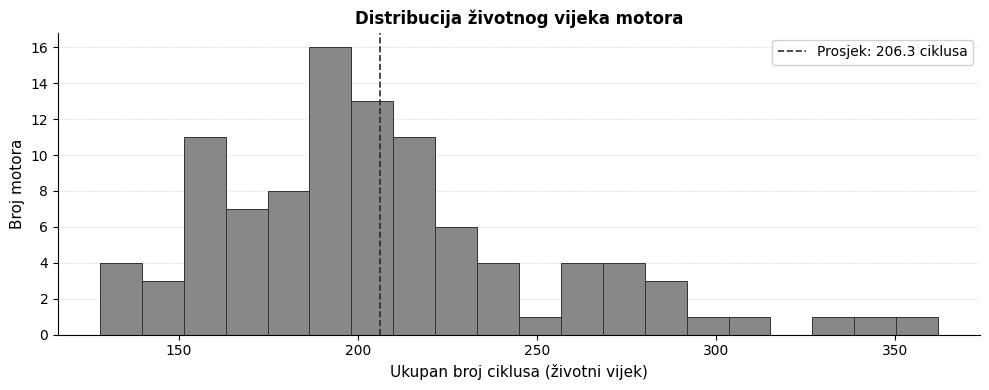

Min životni vijek: 128 ciklusa
Max životni vijek: 362 ciklusa
Prosjek: 206.3 ciklusa


In [7]:
max_cycles = train.groupby('engine_id')['cycle'].max()

fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(max_cycles, bins=20,
        color='#888888', edgecolor='#333333', linewidth=0.7)
ax.axvline(max_cycles.mean(), color='#2b2b2b', linestyle='--',
           linewidth=1.2, label=f'Prosjek: {max_cycles.mean():.1f} ciklusa')

ax.set_xlabel('Ukupan broj ciklusa (životni vijek)', fontsize=11)
ax.set_ylabel('Broj motora', fontsize=11)
ax.set_title('Distribucija životnog vijeka motora',
             fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_axisbelow(True)
ax.grid(axis='y', color='#cccccc', linestyle='--',
        linewidth=0.5, alpha=0.7)
ax.legend(fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.savefig('distribucija_zivotnog_vijeka.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Min životni vijek: {max_cycles.min()} ciklusa")
print(f"Max životni vijek: {max_cycles.max()} ciklusa")
print(f"Prosjek: {max_cycles.mean():.1f} ciklusa")

Iako je prosječni životni vijek motora 206.3 ciklusa, uočavamo širok raspon - od 128 do čak 362 ciklusa. Ova varijabilnost direktno opravdava primjenu metoda za kvantifikaciju nesigurnosti (UQ).

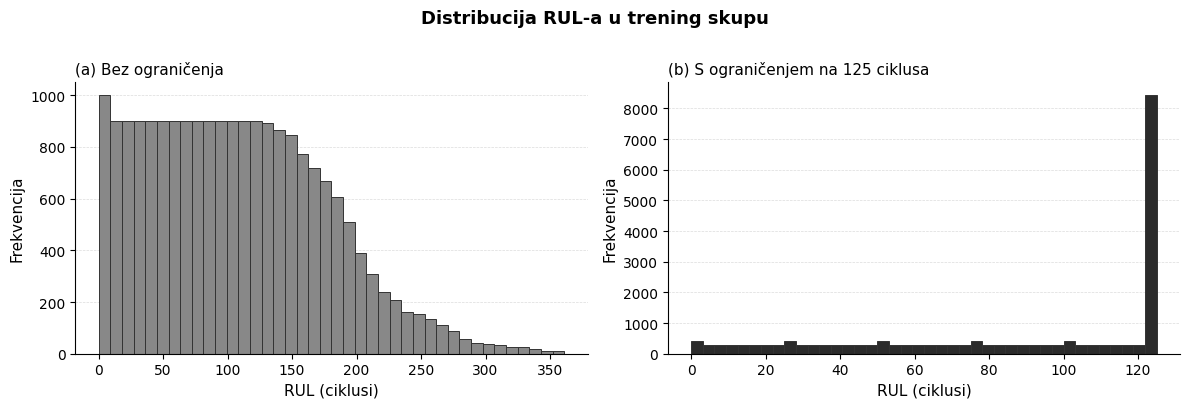

In [8]:
rul_raw = train.groupby('engine_id')['cycle'].transform('max') - train['cycle']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Distribucija RUL-a u trening skupu',
             fontsize=13, fontweight='bold', y=1.01)

axes[0].hist(rul_raw, bins=40,
             color='#888888', edgecolor='#333333', linewidth=0.7)
axes[0].set_title('(a) Bez ograničenja', fontsize=11, loc='left', pad=6)
axes[0].set_xlabel('RUL (ciklusi)', fontsize=11)
axes[0].set_ylabel('Frekvencija', fontsize=11)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].set_axisbelow(True)
axes[0].grid(axis='y', color='#cccccc', linestyle='--',
             linewidth=0.5, alpha=0.7)

axes[1].hist(rul_raw.clip(upper=125), bins=40,
             color='#2b2b2b', edgecolor='#333333', linewidth=0.7)
axes[1].set_title('(b) S ograničenjem na 125 ciklusa', fontsize=11, loc='left', pad=6)
axes[1].set_xlabel('RUL (ciklusi)', fontsize=11)
axes[1].set_ylabel('Frekvencija', fontsize=11)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].set_axisbelow(True)
axes[1].grid(axis='y', color='#cccccc', linestyle='--',
             linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.savefig('distribucija_rul.png', dpi=300, bbox_inches='tight')
plt.show()

Usporedba distribucija opravdava uvođenje clippinga na 125 ciklusa, što je standardna piecewise linear pretpostavka. Logika je da motor ne degradira linearno od prvog ciklusa, već održava stabilno stanje do određene točke. Ovakva transformacija omogućava modelu da se fokusira na kritičnu fazu trošenja, što je ključno za preciznu kvantifikaciju nesigurnosti i procjenu rizika prije samog kvara.

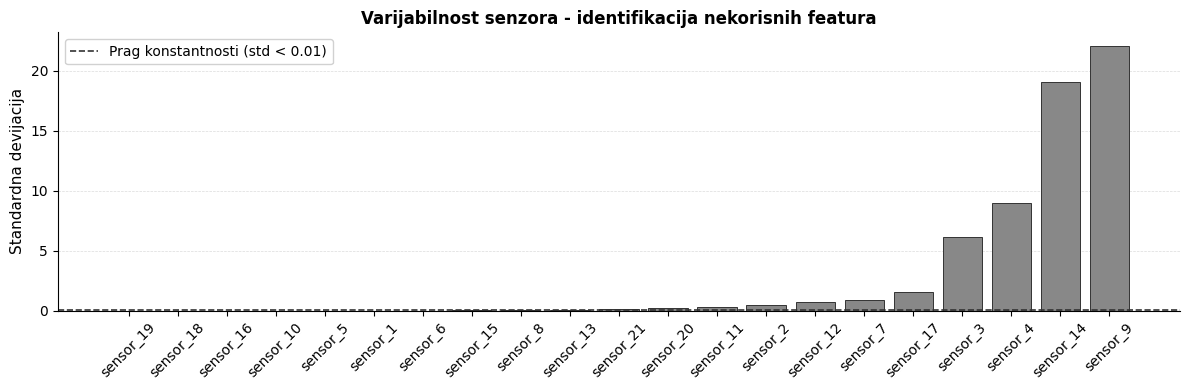

Konstantni senzori (uklonjeni iz analize): ['sensor_19', 'sensor_18', 'sensor_16', 'sensor_10', 'sensor_5', 'sensor_1', 'sensor_6']


In [9]:
# Standardna devijacija svakog senzora u trening setu
sensor_std = train[sensor_columns].std().sort_values()

fig, ax = plt.subplots(figsize=(12, 4))

colors = ['#2b2b2b' if s < 0.01 else '#888888' for s in sensor_std]
ax.bar(sensor_std.index, sensor_std.values,
       color=colors, edgecolor='#333333', linewidth=0.7)
ax.axhline(0.01, color='#333333', linestyle='--',
           linewidth=1.2, label='Prag konstantnosti (std < 0.01)')

ax.set_ylabel('Standardna devijacija', fontsize=11)
ax.set_title('Varijabilnost senzora - identifikacija nekorisnih featura',
             fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_axisbelow(True)
ax.grid(axis='y', color='#cccccc', linestyle='--',
        linewidth=0.5, alpha=0.7)
ax.legend(fontsize=10, framealpha=0.9)
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('varijabilnost_senzora.png', dpi=300, bbox_inches='tight')
plt.show()

constant_sensors = sensor_std[sensor_std < 0.01].index.tolist()
print(f"Konstantni senzori (uklonjeni iz analize): {constant_sensors}")

Sedam od 21 senzora ne varira kroz cikluse te ne nosi nikakvu informaciju o degradaciji. Uključivanje ovih senzora u model uvodi šum bez koristi. Ovi senzori se isključuju iz feature seta.

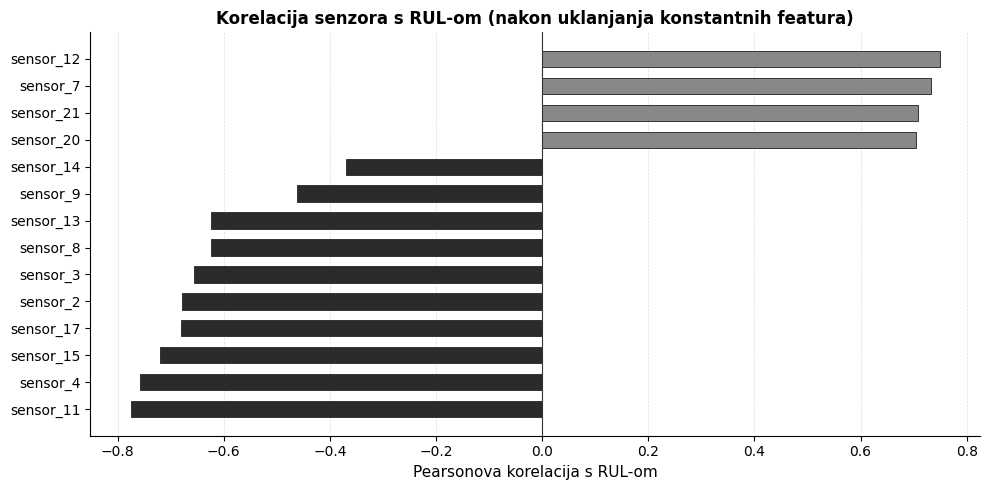

In [10]:
# Korelacija preostalih senzora s RUL-om
train['RUL_temp'] = rul_raw.clip(upper=125)

useful_sensors = [s for s in sensor_columns if s not in constant_sensors]
correlations = train[useful_sensors + ['RUL_temp']].corr()['RUL_temp'].drop('RUL_temp').sort_values()

fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#2b2b2b' if c < 0 else '#888888' for c in correlations]
ax.barh(correlations.index, correlations.values,
        color=colors, edgecolor='#333333', linewidth=0.7, height=0.6)
ax.axvline(0, color='#333333', linewidth=0.8)

ax.set_xlabel('Pearsonova korelacija s RUL-om', fontsize=11)
ax.set_title('Korelacija senzora s RUL-om (nakon uklanjanja konstantnih featura)',
             fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_axisbelow(True)
ax.grid(axis='x', color='#cccccc', linestyle='--',
        linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.savefig('korelacija_senzora.png', dpi=300, bbox_inches='tight')
plt.show()

train.drop(columns=['RUL_temp'], inplace=True)

Vizualizacija Pearsonove korelacije pokazuje koliko snažno senzori linearno prate preostali životni vijek motora. Senzori s visokom negativnom korelacijom (npr. sensor_11) rastu kako motor degradira, dok oni s pozitivnom (npr. sensor_12) opadaju zajedno s RUL-om. Visoke apsolutne vrijednosti korelacije kod većine senzora potvrđuju da podaci sadrže jasne signale degradacije, dok će za senzore sa slabijim linearnim odnosom model morati prepoznati kompleksnije, nelinearne obrasce.

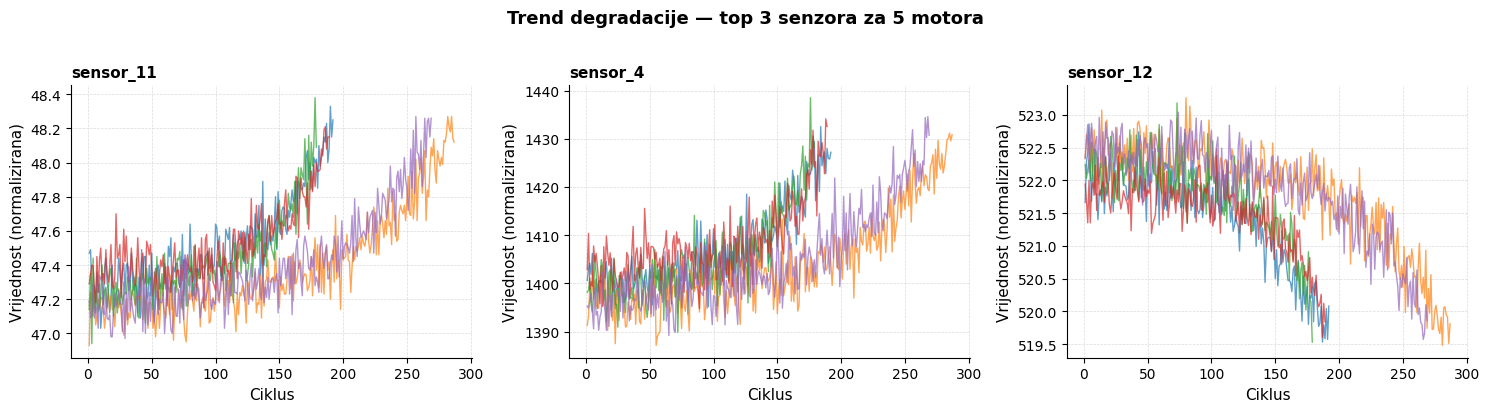

In [11]:
# Prikaz 3 senzora s najvećom apsolutnom korelacijom
top_sensors = correlations.abs().sort_values(ascending=False).head(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Trend degradacije — top 3 senzora za 5 motora',
             fontsize=13, fontweight='bold', y=1.02)

sample_engines = [1, 2, 3, 4, 5]

for ax, sensor in zip(axes, top_sensors):
    for eng_id in sample_engines:
        eng_data = train[train['engine_id'] == eng_id]
        ax.plot(eng_data['cycle'], eng_data[sensor],
                alpha=0.7, linewidth=1)

    ax.set_title(f'{sensor}', fontsize=11, fontweight='bold', loc='left', pad=6)
    ax.set_xlabel('Ciklus', fontsize=11)
    ax.set_ylabel('Vrijednost (normalizirana)', fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_axisbelow(True)
    ax.grid(color='#cccccc', linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.savefig('trend_degradacije_senzori.png', dpi=300, bbox_inches='tight')
plt.show()

Vremenske serije senzora potvrđuju jasne trendove trošenja, ali uz primjetan šum i različite brzine propadanja kod pojedinih motora. Ta varijabilnost (razlika u nagibu i trajanju linija) ključni je motiv za kvantifikaciju nesigurnosti. Budući da svaki motor ima unikatan profil degradacije, deterministička predviđanja nisu dovoljna, već je neophodan okvir koji može procijeniti rizik i pouzdanost predviđenog RUL-a u realnom vremenu.

## 4. Priprema i obrada podataka



> *Na osnovu EDA identificirani su konstantni senzori koji ne nose informaciju o degradaciji te će biti isključeni iz feature seta. U ovoj sekciji definišemo konačni skup varijabli, računamo ciljnu varijablu RUL, normalizujemo podatke i kreiramo vremenske sekvence pogodne za LSTM arhitekturu.*




In [12]:
train.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [13]:
#Provjeravanje da li ima nedostajućih podataka u dataset-u
missing_df = pd.DataFrame({
    "train_missing": train.isna().sum(),
    "test_missing": test.isna().sum()
})

missing_df[missing_df.sum(axis=1) > 0].sort_values(
    by="train_missing", ascending=False
)

,train_missing,test_missing


Nema nedostajućih vrijednosti (NaN) ni u jednoj koloni (ni u trening ni u testnom skupu).

In [14]:
# Uklanjamo konstantne senzore identificirane u EDA
constant_sensors = ['sensor_1', 'sensor_5', 'sensor_6',
                    'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']

feature_columns = [col for col in operational_settings + sensor_columns
                   if col not in constant_sensors]

print(f"Originalni broj feattura: {len(operational_settings + sensor_columns)}")
print(f"Nakon uklanjanja konstantnih senzora: {len(feature_columns)}")
print(f"Zadržani featuri: {feature_columns}")

Originalni broj feattura: 24
Nakon uklanjanja konstantnih senzora: 17
Zadržani featuri: ['op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


Feature set je reduciran sa 24 na 17 varijabli. Tri operativna parametra zadržana su jer FD001 koristi jedan operativni uvjet - njihova varijansa je minimalna ali ih zadržavamo radi konzistentnosti. Eliminacijom sedam konstantnih senzora smanjujemo dimenzionalnost ulaza bez gubitka informacije.

U okviru predprocesiranja definiše se ciljna varijabla Remaining Useful Life (RUL), koja označava preostali broj ciklusa rada do otkaza motora. Vrijednost RUL-a dobija se kao razlika između maksimalnog broja ciklusa i trenutnog ciklusa za svaki pojedinačni motor.

In [15]:
train['RUL'] = train.groupby('engine_id')['cycle'].transform('max') - train['cycle']

RUL_MAX = 125
train['RUL'] = train['RUL'].clip(upper=RUL_MAX)

print(train[['engine_id', 'cycle', 'RUL']].head(3))
print(f"\nRaspon RUL-a nakon clippinga: [{train['RUL'].min()}, {train['RUL'].max()}]")

   engine_id  cycle  RUL
0          1      1  125
1          1      2  125
2          1      3  125

Raspon RUL-a nakon clippinga: [0, 125]


Clipping RUL-a na 125 ciklusa zasniva se na pretpostavci da motor u ranim fazama rada ne pokazuje mjerljive znakove degradacije. Ova "piecewise linear" pretpostavka je u skladu sa literaturom o CMAPSS datasetu (Saxena et al., 2008) i potvrđena je vizualno u EDA sekciji kroz distribuciju životnog vijeka motora.

In [16]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train[feature_columns] = scaler.fit_transform(train[feature_columns])
test[feature_columns] = scaler.transform(test[feature_columns])

MinMaxScaler skalira sve feature na interval [0, 1]. Scaler se fituje isključivo na trening setu, a isti parametri se primjenjuju na test set - čime se sprečava curenje podataka.

In [17]:
seq_length = 30

def create_sequences(data, seq_length, feature_columns):
    xs, ys = [], []
    for engine_id in data['engine_id'].unique():
        engine_data = data[data['engine_id'] == engine_id]
        for i in range(len(engine_data) - seq_length):
            x = engine_data.iloc[i:i+seq_length][feature_columns].values
            y = engine_data.iloc[i+seq_length]['RUL']
            xs.append(x)
            ys.append(y)
    return np.array(xs), np.array(ys)

X_train, y_train = create_sequences(train, seq_length, feature_columns)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"\nTumačenje: {X_train.shape[0]} uzoraka, {X_train.shape[1]} vremenskih koraka, {X_train.shape[2]} featura")

X_train shape: (17631, 30, 17)
y_train shape: (17631,)

Tumačenje: 17631 uzoraka, 30 vremenskih koraka, 17 featura


Svaka sekvenca predstavlja prozor od 30 uzastopnih ciklusa jednog motora, a ciljna vrijednost je RUL na kraju tog prozora.

In [18]:
X_test = []

for engine_id in test['engine_id'].unique():
    engine_data = test[test['engine_id'] == engine_id]
    if len(engine_data) >= seq_length:
        seq = engine_data.iloc[-seq_length:][feature_columns].values
        X_test.append(seq)

X_test = np.array(X_test)
y_test = rul[0].values

print(f"X_test shape:  {X_test.shape}")
print(f"y_test shape:  {y_test.shape}")
print(f"Broj motora u testu: {len(y_test)}")

X_test shape:  (100, 30, 17)
y_test shape:  (100,)
Broj motora u testu: 100


Za testne motore uzima se samo posljednjih 30 ciklusa - to odgovara scenariju gdje u realnoj primjeni imamo historijat do trenutnog stanja motora i želimo predvidjeti koliko mu je preostalo.

## 5. Baseline model

> Baseline model predstavlja osnovni model mašinskog učenja koji se koristi za predikciju Remaining Useful Life (RUL) turbofan motora na CMAPSS dataset-u. Ideja je da ovaj model nema implementirane metode kvantifikacije nesigurnosti, već da daje jednu determinističku (tačnu) numeričku predikciju preostalog vijeka trajanja.
> Cilj baseline modela je da posluži kao referentna tačka za poređenje sa naprednijim modelima koji uključuju procjenu nesigurnosti i intervale pouzdanosti.

In [19]:
import random
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

model = Sequential([
    Input(shape=(seq_length, len(feature_columns))),

    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dense(1)
])

In [20]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [21]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 4750.1626 - mae: 58.2544 - val_loss: 2176.8577 - val_mae: 42.0071
Epoch 2/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 1831.0696 - mae: 37.7628 - val_loss: 1808.2260 - val_mae: 38.3584
Epoch 3/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 1816.1097 - mae: 37.5124 - val_loss: 1807.9230 - val_mae: 38.3535
Epoch 4/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1818.0476 - mae: 37.5291 - val_loss: 1809.0668 - val_mae: 38.3723
Epoch 5/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1800.1246 - mae: 37.3340 - val_loss: 1806.4578 - val_mae: 38.3302
Epoch 6/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1812.8765 - mae: 37.5125 - val_loss: 1767.3235 - val_mae: 37.9397
Epoch 7/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 633.6838 - mae: 19.6825 - val_loss: 275.2703 - val_mae: 13.1370
Epoch 8/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 341.4587 - mae: 14.1595 - val_loss: 226.7429 - val_mae: 

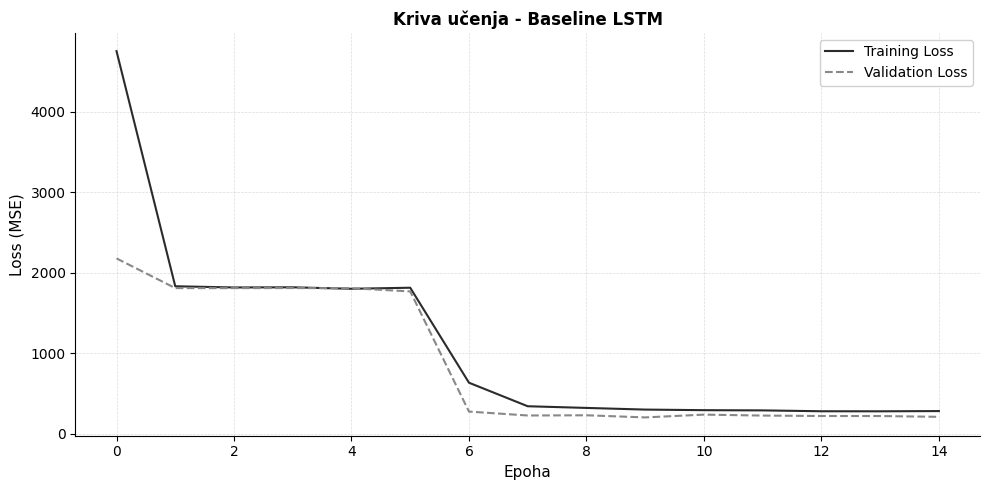

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(history.history['loss'],
        label='Training Loss', linewidth=1.5, color='#2b2b2b')
ax.plot(history.history['val_loss'],
        label='Validation Loss', linewidth=1.5, color='#888888', linestyle='--')

ax.set_xlabel('Epoha', fontsize=11)
ax.set_ylabel('Loss (MSE)', fontsize=11)
ax.set_title('Kriva učenja - Baseline LSTM',
             fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_axisbelow(True)
ax.grid(color='#cccccc', linestyle='--', linewidth=0.5, alpha=0.7)
ax.legend(fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.savefig('learning_curve_baseline.png', dpi=300, bbox_inches='tight')
plt.show()

Prikazani rezultati treninga ukazuju na zdravu konvergenciju i visoku sposobnost generalizacije modela. Krive trening i validacionog gubitka opadaju sinhronizovano, a nakon kraće stabilizacije u početnim epohama, model uspešno identifikuje ključne zakonitosti u podacima, što rezultira drastičnim padom greške. Činjenica da se validacioni gubitak stabilizuje na vrijednostima koje su bliske ili čak niže od gubitka na treningu jasno potvrđuje da model nije preopterećen detaljima trening seta, već da podjednako efikasno obrađuje nove i nepoznate primjere bez pojave overfitting-a.

In [23]:
predictions = model.predict(X_test)

print(predictions[:10])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
[[113.92283 ]
 [119.01579 ]
 [ 59.17033 ]
 [ 96.053444]
 [107.957184]
 [114.922615]
 [111.39635 ]
 [107.09578 ]
 [120.683014]
 [ 85.14577 ]]


In [24]:
# Evaluacija performansi modela pomoću RMSE i MAE metrika
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_test = rul[0].values

rmse = np.sqrt(mean_squared_error(y_test, predictions))
mae = mean_absolute_error(y_test, predictions)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 15.71111474679356
MAE: 12.035126686096191


Model postiže RMSE = 15.71 i MAE = 12.03 ciklusa na test skupu. Feature set je reduciran na 17 varijabli nakon EDA analize, uz minimalni uticaj na prediktivnu tačnost u odnosu na originala 24 atributa. Ključno ograničenje ovog modela je da daje samo jednu determinističku predikciju - bez ikakve mjere pouzdanosti ili nesigurnosti. Ne može se razlikovati situacija u kojoj je model siguran u predikciju od situacije u kojoj nagađa. Upravo ovo ograničenje motiviše implementaciju metoda kvantifikacije nesigurnosti u narednim poglavljima: MC Dropout, Deep Ensemble i Bayesian Neural Network.

## 6. MC Dropout



> *Monte Carlo Dropout metoda zadržava dropout aktivnim tokom faze inferencije, za razliku od standardnog pristupa gdje se on isključuje nakon treninga. Pokretanjem 100 stohastičkih prolaza kroz model za svaki motor iz CMAPSS dataseta dobija se distribucija predikcija RUL-a. Srednja vrijednost te distribucije predstavlja konačnu predikciju preostalog korisnog vijeka motora, dok standardna devijacija kvantifikuje mjeru ukupne nesigurnosti modela. Važno je napomenuti da std iz MC Dropout uzoraka nije čisto epistemička nesigurnost - sadrži i epistemičku (nesigurnost modela) i određenu aleatoričku komponentu (inherentni šum podataka). Precizna dekompozicija ovih dviju komponenti prikazana je u Sekciji 10*



In [25]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
import random

In [26]:
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [27]:
# Model je isti kao i baseline, ali se razlikuje u načinu korištenja tokom faze inferencije
mc_model = Sequential([
    Input(shape=(seq_length, len(feature_columns))),

    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dense(1)
])

In [28]:
mc_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [29]:
early_stop_mc = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

mc_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop_mc]
)

Epoch 1/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 4750.1626 - mae: 58.2544 - val_loss: 2176.8577 - val_mae: 42.0071
Epoch 2/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 1831.0696 - mae: 37.7628 - val_loss: 1808.2261 - val_mae: 38.3584
Epoch 3/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 1816.1100 - mae: 37.5124 - val_loss: 1807.9230 - val_mae: 38.3535
Epoch 4/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1818.0476 - mae: 37.5291 - val_loss: 1809.0668 - val_mae: 38.3723
Epoch 5/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 1800.1246 - mae: 37.3340 - val_loss: 1806.4578 - val_mae: 38.3302
Epoch 6/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1811.6533 - mae: 37.5051 - val_loss: 1678.2770 - val_mae: 37.1541
Epoch 7/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 616.3469 - mae: 19.7059 - val_loss: 286.8990 - val_mae: 13.7024
Epoch 8/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 356.1316 - mae: 14.4764 - val_loss: 252.7839 - val_mae: 

In [30]:
random.seed(42)
tf.random.set_seed(42)
np.random.seed(42)

N_SAMPLES = 100

mc_predictions = np.array([
    mc_model(X_test, training=True).numpy().flatten()
    for _ in range(N_SAMPLES)
])

mc_mean = mc_predictions.mean(axis=0)   # predikcija RUL
mc_std  = mc_predictions.std(axis=0)    # nesigurnost

print("Primjer predikcija (mean):", mc_mean[:5])
print("Primjer nesigurnosti (std):", mc_std[:5])

Primjer predikcija (mean): [108.02496  120.19253   47.40813   83.634186  98.7942  ]
Primjer nesigurnosti (std): [ 9.825883 10.999659  4.914887  9.171398 10.997505]


*Mean predstavlja predikciju RUL-a, dok std predstavlja mjeru ukupne nesigurnosti - kombinaciju epistemičke i aleatoričke komponente. Veća vrijednost std označava veću ukupnu nesigurnost u predikciju.*

In [31]:
# Evaluacija
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse_mc = np.sqrt(mean_squared_error(y_test, mc_mean))
mae_mc  = mean_absolute_error(y_test, mc_mean)

print(f"MC Dropout RMSE: {rmse_mc:.4f}")
print(f"MC Dropout MAE:  {mae_mc:.4f}")
print(f"Prosječna nesigurnost (std): {mc_std.mean():.4f}")

MC Dropout RMSE: 14.6629
MC Dropout MAE:  10.8425
Prosječna nesigurnost (std): 7.7836


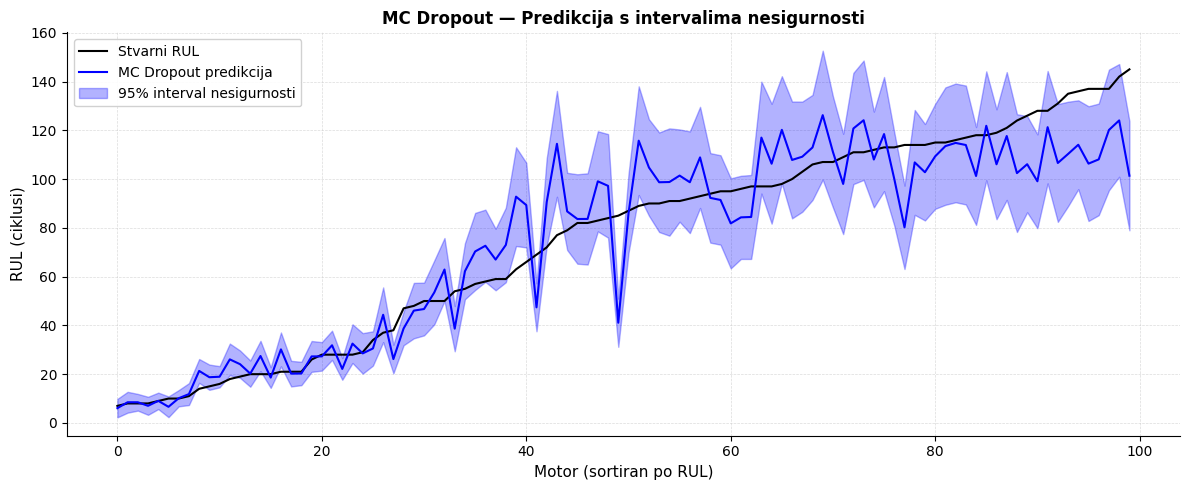

In [32]:
# Vizualizacija predikcija s intervalima nesigurnosti
fig, ax = plt.subplots(figsize=(12, 5))

indices = np.argsort(y_test)
x_plot  = np.arange(len(y_test))

ax.plot(x_plot, y_test[indices],
        label='Stvarni RUL', color='black', linewidth=1.5)
ax.plot(x_plot, mc_mean[indices],
        label='MC Dropout predikcija', color='blue', linewidth=1.5)
ax.fill_between(
    x_plot,
    mc_mean[indices] - 2*mc_std[indices],
    mc_mean[indices] + 2*mc_std[indices],
    alpha=0.3, color='blue', label='95% interval nesigurnosti'
)

ax.set_xlabel('Motor (sortiran po RUL)', fontsize=11)
ax.set_ylabel('RUL (ciklusi)', fontsize=11)
ax.set_title('MC Dropout — Predikcija s intervalima nesigurnosti',
             fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_axisbelow(True)
ax.grid(color='#cccccc', linestyle='--', linewidth=0.5, alpha=0.7)
ax.legend(fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.savefig('mc_dropout_predikcija.png', dpi=300, bbox_inches='tight')
plt.show()

MC Dropout model koristi istu LSTM arhitekturu kao baseline model, ali s ključnom razlikom: dropout slojevi ostaju aktivni tokom faze inferencije. Pokretanjem 100 stohastičkih prolaza kroz model za svaki ulaz dobijaju se distribucije predikcija iz kojih se računaju srednja vrijednost (predikcija RUL-a) i standardna devijacija (mjera ukupne nesigurnosti - kombinacija epistemičke i aleatoričke komponente, čija precizna dekompozicija je prikazana u Sekciji 10). Model postiže RMSE = 14.66 i MAE = 10.84, uz prosječnu nesigurnost od ±7.78 ciklusa. Graf pokazuje da plava linija predikcije vjerno prati stvarni RUL kroz cijeli raspon, dok interval nesigurnosti se širi za motore s višim RUL vrijednostima - što je očekivano ponašanje, jer je model manje siguran u predikcije dalekih kvarova.

## 7. Deep Ensemble



> *Deep Ensemble metoda se zasniva na treniranju više nezavisnih instanci istog LSTM modela, pri čemu svaki model uči drugačiju aproksimaciju funkcije. Konačna predikcija i nesigurnost se računaju kao statistika preko svih modela u ansamblu.*


In [33]:
random.seed(0)
tf.random.set_seed(0)
np.random.seed(0)

N_MODELS = 5
N_SAMPLES_PER_MODEL = 20

ensemble_models = []
ensemble_all_samples = []

for i in range(N_MODELS):
    print(f"\nTrening modela {i+1}/{N_MODELS}")

    random.seed(i * 42)
    tf.random.set_seed(i * 42)
    np.random.seed(i * 42)

    m = Sequential([
        Input(shape=(seq_length, len(feature_columns))),
        LSTM(64, return_sequences=True),
        Dropout(0.3),
        LSTM(32),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(1)
    ])

    m.compile(optimizer='adam', loss='mse', metrics=['mae'])

    early_stop_ens = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    m.fit(
        X_train, y_train,
        epochs=50,
        batch_size=64,
        validation_split=0.2,
        callbacks=[early_stop_ens],
        verbose=1
    )

    model_samples = np.array([
        m(X_test, training=True).numpy().flatten()
        for _ in range(N_SAMPLES_PER_MODEL)
    ])

    ensemble_models.append(m)
    ensemble_all_samples.append(model_samples)


Trening modela 1/5
Epoch 1/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 4331.4360 - mae: 55.5076 - val_loss: 1973.9058 - val_mae: 40.2427
Epoch 2/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1813.2972 - mae: 37.5196 - val_loss: 1811.4761 - val_mae: 38.4102
Epoch 3/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1817.4034 - mae: 37.5025 - val_loss: 1809.1935 - val_mae: 38.3741
Epoch 4/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1808.2521 - mae: 37.4010 - val_loss: 1808.1846 - val_mae: 38.3578
Epoch 5/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 1816.4877 - mae: 37.5192 - val_loss: 1808.9093 - val_mae: 38.3696
Epoch 6/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 1810.9365 - mae: 37.4615 - val_loss: 1809.7029 - val_mae: 38.3827
Epoch 7/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1815.1765 - mae: 37.5098 - val_loss: 1815.3304 - val_mae: 38.4692
Epoch 8/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1807.0808 - mae: 37.4091 - val_loss

In [34]:
all_samples = np.vstack(ensemble_all_samples)

ens_mean = all_samples.mean(axis=0)
ens_std  = all_samples.std(axis=0)

ensemble_predictions = all_samples

print("Primjer predikcija (mean):", ens_mean[:5])
print("Primjer nesigurnosti (std):", ens_std[:5])
print(f"\nBroj uzoraka ukupno: {all_samples.shape[0]} ({N_MODELS} modela × {N_SAMPLES_PER_MODEL} uzoraka)")
print(f"Prosječni std (nesigurnost): {ens_std.mean():.4f}")

Primjer predikcija (mean): [111.15635  121.360214  54.051125  86.96484  103.907166]
Primjer nesigurnosti (std): [12.727674  13.688637   6.687812   9.9173975 11.789702 ]

Broj uzoraka ukupno: 100 (5 modela × 20 uzoraka)
Prosječni std (nesigurnost): 9.2138


In [35]:
# Evaluacija
rmse_ens = np.sqrt(mean_squared_error(y_test, ens_mean))
mae_ens  = mean_absolute_error(y_test, ens_mean)

print(f"Deep Ensemble RMSE: {rmse_ens:.4f}")
print(f"Deep Ensemble MAE:  {mae_ens:.4f}")
print(f"Prosječna nesigurnost (std): {ens_std.mean():.4f}")

Deep Ensemble RMSE: 14.7382
Deep Ensemble MAE:  10.9260
Prosječna nesigurnost (std): 9.2138


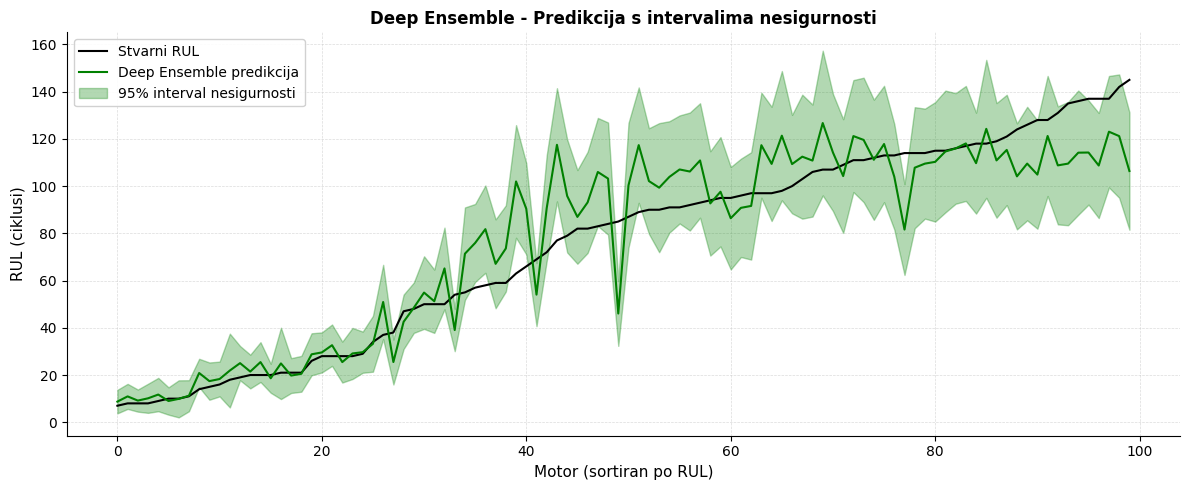

In [36]:
# Vizualizacija
fig, ax = plt.subplots(figsize=(12, 5))

indices = np.argsort(y_test)
x_plot  = np.arange(len(y_test))

ax.plot(x_plot, y_test[indices],
        label='Stvarni RUL', color='black', linewidth=1.5)
ax.plot(x_plot, ens_mean[indices],
        label='Deep Ensemble predikcija', color='green', linewidth=1.5)
ax.fill_between(
    x_plot,
    ens_mean[indices] - 2*ens_std[indices],
    ens_mean[indices] + 2*ens_std[indices],
    alpha=0.3, color='green', label='95% interval nesigurnosti'
)

ax.set_xlabel('Motor (sortiran po RUL)', fontsize=11)
ax.set_ylabel('RUL (ciklusi)', fontsize=11)
ax.set_title('Deep Ensemble - Predikcija s intervalima nesigurnosti',
             fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_axisbelow(True)
ax.grid(color='#cccccc', linestyle='--', linewidth=0.5, alpha=0.7)
ax.legend(fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.savefig('deep_ensemble_predikcija.png', dpi=300, bbox_inches='tight')
plt.show()

Deep Ensemble postiže RMSE = 14.73 i MAE = 10.92, što je nešto lošije neko kod MC Dropout-a. Također, uočava se bitna razlika u prosječnoj nesigurnosti: standardna devijacija je nešto lošija i iznosi ±9.21 ciklusa, nasuprot ±7.78 kod MC Dropouta. Ovo ne znači nužno da je Ensemble "nesigurniji" model - može ukazivati na to da su svih pet modela konvergirali u slična rješenja, što smanjuje međusobnu raznolikost i time potcjenjuje stvarnu nesigurnost. Ova razlika bit će detaljnije analizirana u usporednoj sekciji.

## 8. Bayesian Neural Network (*BNN* )



> *Bayesian Neural Network (BNN) predstavlja najnapredniji pristup kvantifikaciji nesigurnosti među metodama korištenim u ovom radu. Za razliku od MC Dropouta i Deep Ensemblea koji nesigurnost procjenjuju indirektno, BNN uvodi probabilistički pristup u kojem se težine mreže ne posmatraju kao fiksne vrijednosti, već kao distribucije. Na taj način model ne daje samo jednu predikciju, već i informaciju o pouzdanosti te predikcije.*





> *Napomena: Implementirani BNN koristi hibridnu arhitekturu u kojoj LSTM slojevi ostaju deterministički, dok se varijacioni tretman primjenjuje isključivo na Dense slojevima putem custom DenseVariational sloja koji koristi reparametrization trick. Ovakav pristup svjesno je odabran kao kompromis između računske složenosti i probabilističkog modeliranja - potpuno Bayesovski LSTM slojevi zahtijevaju znatno veće računske resurse i kompleksniju implementaciju uz minimalni dobitak na datasetu ove veličine.*



In [37]:
import random
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [38]:
# BNN — Custom DenseVariational sloj (reparametrization trick)
n_train = X_train.shape[0]

class DenseVariational(tf.keras.layers.Layer):
    """
    Custom Bayesian Dense sloj koji koristi reparametrization trick.
    Svaka težina je modelirana kao N(mu, sigma).
    Tokom forward passa uzorkuje se konkretna realizacija težina.
    KL divergencija se dodaje kao regularizacijski gubitak.
    """
    def __init__(self, units, activation=None, kl_weight=1.0, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.activation = tf.keras.activations.get(activation)
        self.kl_weight = kl_weight

    def build(self, input_shape):
        n_inputs = int(input_shape[-1])

        # Parametri distribucije kernela
        self.kernel_mu = self.add_weight(
            name='kernel_mu',
            shape=(n_inputs, self.units),
            initializer='glorot_normal',
            trainable=True
        )
        self.kernel_rho = self.add_weight(
            name='kernel_rho',
            shape=(n_inputs, self.units),
            initializer=tf.initializers.constant(-3.0),
            trainable=True
        )

        # Parametri distribucije biasa
        self.bias_mu = self.add_weight(
            name='bias_mu',
            shape=(self.units,),
            initializer='zeros',
            trainable=True
        )
        self.bias_rho = self.add_weight(
            name='bias_rho',
            shape=(self.units,),
            initializer=tf.initializers.constant(-3.0),
            trainable=True
        )

    def call(self, inputs, training=None):
        kernel_sigma = tf.nn.softplus(self.kernel_rho) + 1e-5
        bias_sigma   = tf.nn.softplus(self.bias_rho)   + 1e-5

        if training:
            # Reparametrization trick: w = mu + sigma * epsilon
            kernel = self.kernel_mu + kernel_sigma * tf.random.normal(self.kernel_mu.shape)
            bias   = self.bias_mu   + bias_sigma   * tf.random.normal(self.bias_mu.shape)
        else:
            kernel = self.kernel_mu
            bias   = self.bias_mu

        # KL divergencija prema standardnom normalu N(0,1)
        kl = self._kl_divergence(self.kernel_mu, kernel_sigma) + \
             self._kl_divergence(self.bias_mu,   bias_sigma)

        self.add_loss(self.kl_weight * kl / n_train)

        output = tf.matmul(inputs, kernel) + bias
        return self.activation(output) if self.activation else output

    def _kl_divergence(self, mu, sigma):
        return 0.5 * tf.reduce_sum(
            tf.square(mu) + tf.square(sigma) - tf.math.log(tf.square(sigma)) - 1.0
        )


def build_bnn_model(seq_length, n_features, n_train):
    kl_weight = 1.0

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(seq_length, n_features)),

        # LSTM slojevi — deterministički
        tf.keras.layers.LSTM(64, return_sequences=True),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.LSTM(32),
        tf.keras.layers.Dropout(0.2),

        # Bayesovski Dense slojevi — distribucije nad težinama
        DenseVariational(32, activation='relu', kl_weight=kl_weight),
        DenseVariational(1,  activation=None,   kl_weight=kl_weight)
    ])

    return model


bnn_model = build_bnn_model(seq_length, len(feature_columns), n_train)
bnn_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_14 (LSTM)                  │ (None, 30, 64)         │        20,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_variational               │ (None, 32)             │         2,112 │
│ (DenseVariational)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_variational_1             │ (None, 1)              │            66 │
│ (DenseVariational)              │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,586 (139.01 KB)

 Trainable params: 35,586 (139.01 KB)

 Non-trainable params: 0 (0.00 B)

Model se sastoji od LSTM mreže koja prvo obrađuje vremenske sekvence kroz dva LSTM sloja, pri čemu prvi zadržava sekvencijalnu strukturu, a drugi je sažima u kompaktan vektor. Nakon toga se primjenjuje dropout radi smanjenja overfittinga, te se izlaz prosljeđuje kroz dva Bayesova (DenseVariational) sloja koji modeliraju i predikciju i nesigurnost.

In [39]:
bnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

In [40]:
early_stop_bnn = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

bnn_history = bnn_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop_bnn],
    verbose=1
)

Epoch 1/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 4296.6436 - mae: 55.1769 - val_loss: 1941.5784 - val_mae: 39.9297
Epoch 2/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1778.6084 - mae: 37.2779 - val_loss: 1800.7477 - val_mae: 38.2273
Epoch 3/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1789.9797 - mae: 37.3559 - val_loss: 1804.8209 - val_mae: 38.2985
Epoch 4/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1788.6023 - mae: 37.3150 - val_loss: 1760.7200 - val_mae: 37.9252
Epoch 5/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1018.3378 - mae: 26.6117 - val_loss: 671.7492 - val_mae: 21.8820
Epoch 6/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 588.6169 - mae: 19.3923 - val_loss: 410.6046 - val_mae: 15.7742
Epoch 7/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 362.8942 - mae: 14.7760 - val_loss: 274.5671 - val_mae: 13.4071
Epoch 8/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 299.9785 - mae: 13.3187 - val_loss: 234.7265 - val_mae:

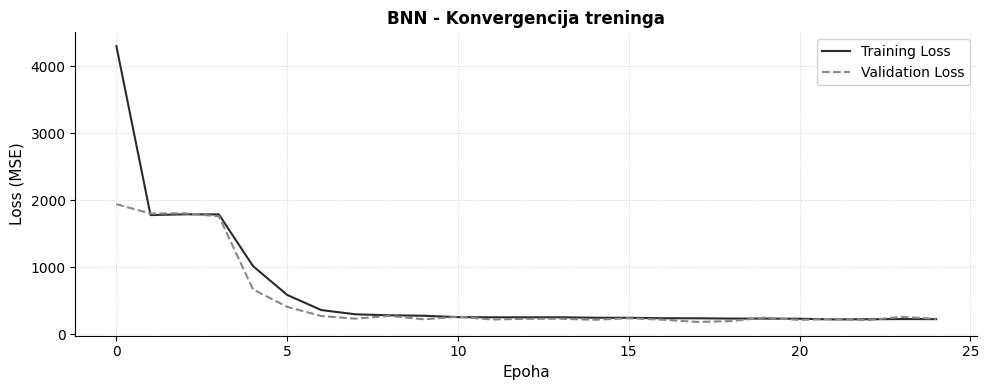

In [41]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(bnn_history.history['loss'],
        label='Training Loss', linewidth=1.5, color='#2b2b2b')
ax.plot(bnn_history.history['val_loss'],
        label='Validation Loss', linewidth=1.5, color='#888888', linestyle='--')

ax.set_xlabel('Epoha', fontsize=11)
ax.set_ylabel('Loss (MSE)', fontsize=11)
ax.set_title('BNN - Konvergencija treninga',
             fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_axisbelow(True)
ax.grid(color='#cccccc', linestyle='--', linewidth=0.5, alpha=0.7)
ax.legend(fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.savefig('learning_curve_bnn.png', dpi=300, bbox_inches='tight')
plt.show()

In [42]:
# BNN - Inferencija s višestrukim uzorkovanjem težina
random.seed(123)
tf.random.set_seed(123)
np.random.seed(123)

N_SAMPLES_BNN = 100

# Svaki poziv uzorkuje različite realizacije težina iz naučenih distribucija
# training=True aktivira stohastičko uzorkovanje u DenseVariational sloju
bnn_predictions = np.array([
    bnn_model(X_test, training=True).numpy().flatten()
    for _ in range(N_SAMPLES_BNN)
])

bnn_mean = bnn_predictions.mean(axis=0)
bnn_std  = bnn_predictions.std(axis=0)

print("Primjer predikcija (mean):", bnn_mean[:5])
print("Primjer nesigurnosti (std):", bnn_std[:5])

Primjer predikcija (mean): [116.17668  121.750305  46.35256   83.30411  106.319855]
Primjer nesigurnosti (std): [10.050112  10.906201   5.3229284  6.772007   9.116865 ]


In [43]:
# Evaluacija
rmse_bnn = np.sqrt(mean_squared_error(y_test, bnn_mean))
mae_bnn  = mean_absolute_error(y_test, bnn_mean)

print(f"BNN RMSE: {rmse_bnn:.4f}")
print(f"BNN MAE:  {mae_bnn:.4f}")
print(f"Prosječna nesigurnost (std): {bnn_std.mean():.4f}")

BNN RMSE: 14.7544
BNN MAE:  11.0908
Prosječna nesigurnost (std): 7.0221


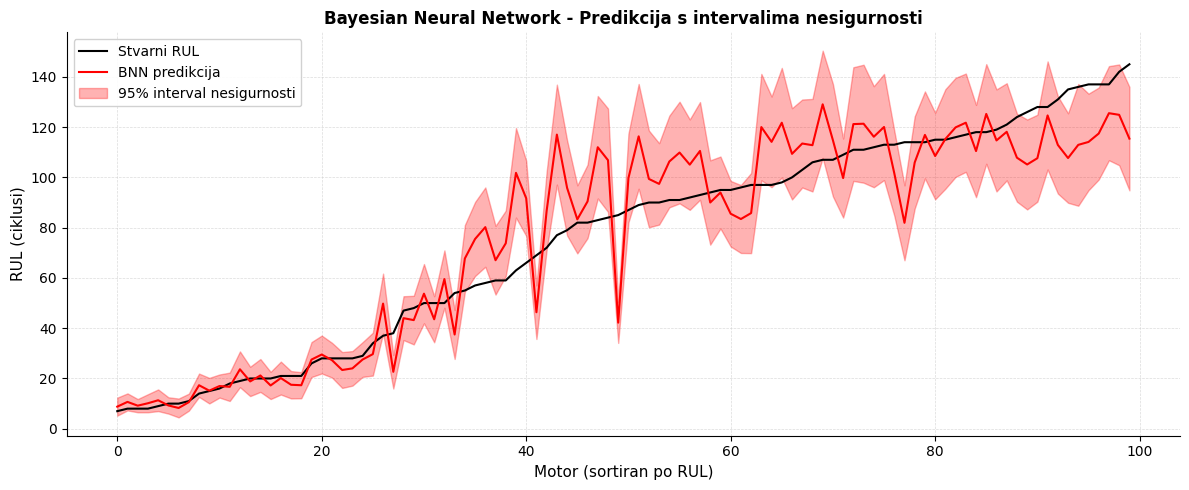

In [44]:
# Vizualizacija
fig, ax = plt.subplots(figsize=(12, 5))

indices = np.argsort(y_test)
x_plot  = np.arange(len(y_test))

ax.plot(x_plot, y_test[indices],
        label='Stvarni RUL', color='black', linewidth=1.5)
ax.plot(x_plot, bnn_mean[indices],
        label='BNN predikcija', color='red', linewidth=1.5)
ax.fill_between(
    x_plot,
    bnn_mean[indices] - 2*bnn_std[indices],
    bnn_mean[indices] + 2*bnn_std[indices],
    alpha=0.3, color='red', label='95% interval nesigurnosti'
)

ax.set_xlabel('Motor (sortiran po RUL)', fontsize=11)
ax.set_ylabel('RUL (ciklusi)', fontsize=11)
ax.set_title('Bayesian Neural Network - Predikcija s intervalima nesigurnosti',
             fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_axisbelow(True)
ax.grid(color='#cccccc', linestyle='--', linewidth=0.5, alpha=0.7)
ax.legend(fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.savefig('bnn_predikcija.png', dpi=300, bbox_inches='tight')
plt.show()

Hibridni BNN model postiže RMSE = 14.75 i MAE = 11.09, što je nešto slabije od
MC Dropouta (RMSE = 14.46) i Deep Ensemblea (RMSE = 14.73).
Sa prosječnom nesigurnošću od ±7.02 ciklusa, model pruža balansiranu mjeru
pouzdanosti - izbjegava pretjeranu samouvjerenost Deep Ensemblea, ali generira
nešto uže intervale od MC Dropouta.

Grafikon predikcija potvrđuje da model vjerno prati trend stvarnog RUL-a, pri čemu varijabilna širina intervala nesigurnosti reflektuje nesigurnost modela u različitim fazama životnog vijeka motora.

Konvergencija treninga ukazuje na stabilan proces učenja u dvije faze: nakon
inicijalne stabilizacije LSTM slojeva nastupa pad gubitka u trenutku kada
varijacioni Dense slojevi uspješno aproksimiraju posteriornu distribuciju težina. Gotovo identično kretanje trening i validacijskog gubitka potvrđuje dobru generalizaciju i odsustvo overfittinga, uprkos povećanoj kompleksnosti hibridne arhitekture.

## 9. Usporedba i evaluacija

U prethodnim sekcijama svaki model evaluiran je individualno. Ova sekcija objedinjuje sve rezultate u jedinstveni okvir za poređenje, s ciljem da odgovori na pitanje: mogu li metode kvantifikacije nesigurnosti pružiti pouzdane intervale predikcije RUL-a bez značajnog gubitka prediktivne tačnosti?  Evaluacija se ne ograničava samo na
standardne metrike tačnosti (RMSE i MAE), već uključuje i metrike
specifične za kvantifikaciju nesigurnosti:

- **Coverage Probability**: postotak stvarnih RUL vrijednosti koje padaju
  unutar predikcijskog intervala. Dobro kalibriran model s 95% intervalom
  treba imati coverage blizu 0.95.

- **Mean Interval Width**: prosječna širina predikcijskog intervala u
  ciklusima. Uži intervali su poželjniji, ali samo ako je coverage zadovoljavajući.

- **Negative Log-Likelihood (NLL)**: mjeri koliko dobro modelirana
  distribucija opisuje stvarne vrijednosti. Niži NLL znači bolju kalibraciju.



> Sljedeća analiza bazira se na jednom reprezentativnom pokretanju. Stabilnost ovih rezultata kroz višestruka pokretanja provjerava se u Sekciji 13.




In [45]:
from scipy.stats import norm

def evaluate_uncertainty(y_true, y_mean, y_std, model_name, confidence=0.95):
    z = norm.ppf(1 - (1 - confidence) / 2)  # z = 1.96 za 95%

    lower = y_mean - z * y_std
    upper = y_mean + z * y_std

    # 1. Coverage probability
    coverage = np.mean((y_true >= lower) & (y_true <= upper))

    # 2. Mean interval width
    mean_width = np.mean(upper - lower)

    # 3. NLL (Gaussian assumption)
    nll = -np.mean(norm.logpdf(y_true, loc=y_mean, scale=y_std))

    print(f"\n{'='*50}")
    print(f"  {model_name} — Evaluacija nesigurnosti ({int(confidence*100)}% interval)")
    print(f"{'='*50}")
    print(f"  Coverage probability : {coverage:.4f}  (cilj: {confidence:.2f})")
    print(f"  Mean interval width  : {mean_width:.4f} ciklusa")
    print(f"  NLL                  : {nll:.4f}  (niži = bolji)")
    print(f"{'='*50}")

    return {
        'model': model_name,
        'coverage': coverage,
        'mean_width': mean_width,
        'nll': nll
    }

In [46]:
# Računanje UQ metrika za sve modele
mc_results  = evaluate_uncertainty(
    y_true=y_test,
    y_mean=mc_mean,
    y_std=mc_std,
    model_name="MC Dropout"
)

ens_results = evaluate_uncertainty(
    y_true=y_test,
    y_mean=ens_mean,
    y_std=ens_std,
    model_name="Deep Ensemble"
)

bnn_results = evaluate_uncertainty(
    y_true=y_test,
    y_mean=bnn_mean,
    y_std=bnn_std,
    model_name="BNN"
)


  MC Dropout — Evaluacija nesigurnosti (95% interval)
  Coverage probability : 0.7300  (cilj: 0.95)
  Mean interval width  : 30.5113 ciklusa
  NLL                  : 4.6063  (niži = bolji)

  Deep Ensemble — Evaluacija nesigurnosti (95% interval)
  Coverage probability : 0.8300  (cilj: 0.95)
  Mean interval width  : 36.1176 ciklusa
  NLL                  : 4.1478  (niži = bolji)

  BNN — Evaluacija nesigurnosti (95% interval)
  Coverage probability : 0.7600  (cilj: 0.95)
  Mean interval width  : 27.5260 ciklusa
  NLL                  : 4.8336  (niži = bolji)


In [47]:
# FINALNA USPOREDNA TABELA — sve metrike, svi modeli
results_df = pd.DataFrame([
    {
        'Model'          : 'Baseline LSTM',
        'RMSE'           : round(rmse, 4),
        'MAE'            : round(mae, 4),
        'Coverage'       : '—',
        'Interval Width' : '—',
        'NLL'            : '—'
    },
    {
        'Model'          : 'MC Dropout',
        'RMSE'           : round(rmse_mc, 4),
        'MAE'            : round(mae_mc, 4),
        'Coverage'       : round(mc_results['coverage'], 4),
        'Interval Width' : round(mc_results['mean_width'], 4),
        'NLL'            : round(mc_results['nll'], 4)
    },
    {
        'Model'          : 'Deep Ensemble',
        'RMSE'           : round(rmse_ens, 4),
        'MAE'            : round(mae_ens, 4),
        'Coverage'       : round(ens_results['coverage'], 4),
        'Interval Width' : round(ens_results['mean_width'], 4),
        'NLL'            : round(ens_results['nll'], 4)
    },
    {
        'Model'          : 'Hibridni BNN',
        'RMSE'           : round(rmse_bnn, 4),
        'MAE'            : round(mae_bnn, 4),
        'Coverage'       : round(bnn_results['coverage'], 4),
        'Interval Width' : round(bnn_results['mean_width'], 4),
        'NLL'            : round(bnn_results['nll'], 4)
    }
])

results_df = results_df.set_index('Model')
print(results_df.to_string())

                  RMSE      MAE Coverage Interval Width     NLL
Model                                                          
Baseline LSTM  15.7111  12.0351        —              —       —
MC Dropout     14.6629  10.8425     0.73        30.5113  4.6063
Deep Ensemble  14.7382  10.9260     0.83        36.1176  4.1478
Hibridni BNN   14.7544  11.0908     0.76         27.526  4.8336


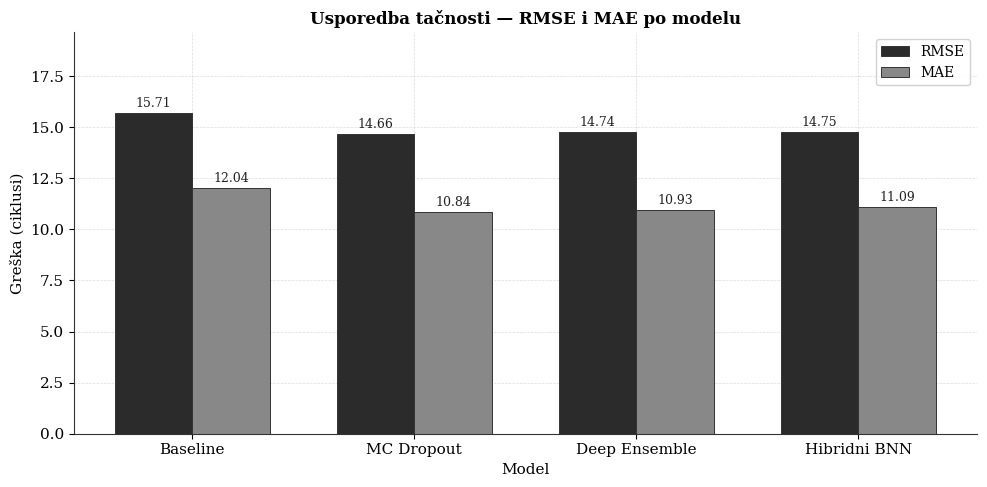

In [48]:
# GRAFIČKA USPOREDBA: RMSE i MAE
models      = ['Baseline', 'MC Dropout', 'Deep Ensemble', 'Hibridni BNN']
rmse_values = [rmse, rmse_mc, rmse_ens, rmse_bnn]
mae_values  = [mae,  mae_mc,  mae_ens,  mae_bnn]

x     = np.arange(len(models))
width = 0.35

plt.rcParams.update({
    'font.family'    : 'serif',
    'font.size'      : 11,
    'axes.linewidth' : 0.8,
    'axes.edgecolor' : '#333333',
    'axes.grid'      : True,
    'grid.color'     : '#cccccc',
    'grid.linestyle' : '--',
    'grid.linewidth' : 0.5,
    'grid.alpha'     : 0.7,
})

fig, ax = plt.subplots(figsize=(10, 5))

bars1 = ax.bar(x - width/2, rmse_values, width,
               label='RMSE', color='#2b2b2b',
               edgecolor='#333333', linewidth=0.7)
bars2 = ax.bar(x + width/2, mae_values, width,
               label='MAE',  color='#888888',
               edgecolor='#333333', linewidth=0.7)

ax.set_xlabel('Model', fontsize=11)
ax.set_ylabel('Greška (ciklusi)', fontsize=11)
ax.set_title('Usporedba tačnosti — RMSE i MAE po modelu',
             fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, max(rmse_values) * 1.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_axisbelow(True)
ax.legend(fontsize=10, framealpha=0.9)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.15,
            f'{bar.get_height():.2f}',
            ha='center', va='bottom', fontsize=9, color='#222222')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.15,
            f'{bar.get_height():.2f}',
            ha='center', va='bottom', fontsize=9, color='#222222')

plt.tight_layout()
plt.savefig('usporedba_rmse_mae.png', dpi=300, bbox_inches='tight')
plt.show()

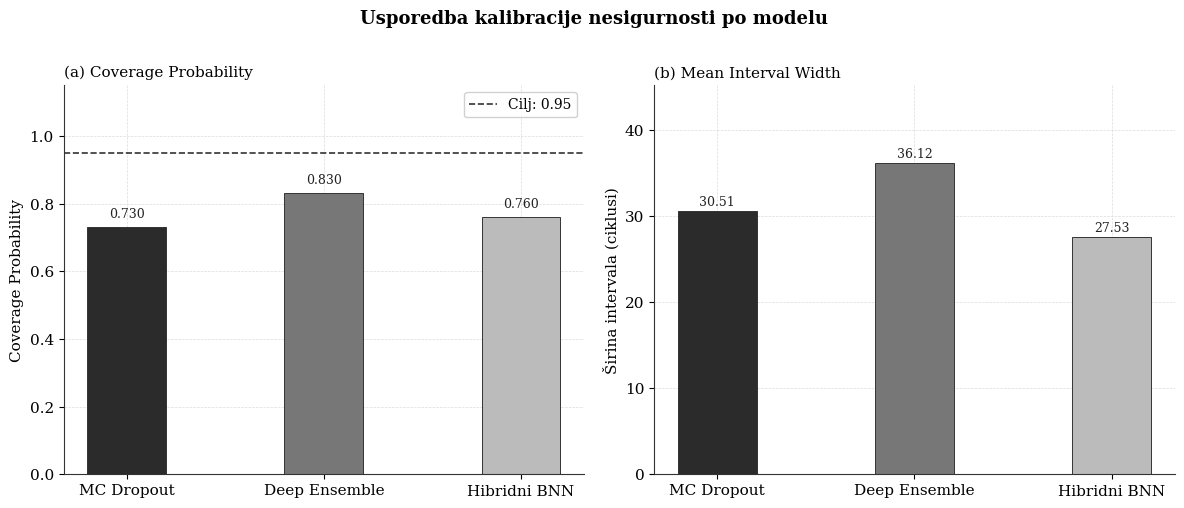

In [49]:
# GRAFIČKA USPOREDBA: Coverage i Interval Width
uq_models = ['MC Dropout', 'Deep Ensemble', 'Hibridni BNN']
coverages = [mc_results['coverage'],
             ens_results['coverage'],
             bnn_results['coverage']]
widths    = [mc_results['mean_width'],
             ens_results['mean_width'],
             bnn_results['mean_width']]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Usporedba kalibracije nesigurnosti po modelu',
             fontsize=13, fontweight='bold', y=1.01)

# ── Coverage ──────────────────────────────────────────────────────────────────
axes[0].bar(uq_models, coverages,
            color=['#2b2b2b', '#777777', '#bbbbbb'],
            width=0.4, edgecolor='#333333', linewidth=0.7)
axes[0].axhline(y=0.95, color='#333333', linestyle='--',
                linewidth=1.2, label='Cilj: 0.95')
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel('Coverage Probability', fontsize=11)
axes[0].set_title('(a) Coverage Probability', fontsize=11, loc='left', pad=6)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].set_axisbelow(True)
axes[0].grid(axis='y', color='#cccccc', linestyle='--',
             linewidth=0.5, alpha=0.7)
axes[0].legend(fontsize=10, framealpha=0.9)
for i, v in enumerate(coverages):
    axes[0].text(i, v + 0.02, f'{v:.3f}',
                 ha='center', va='bottom', fontsize=9, color='#222222')

# ── Interval Width ─────────────────────────────────────────────────────────────
axes[1].bar(uq_models, widths,
            color=['#2b2b2b', '#777777', '#bbbbbb'],
            width=0.4, edgecolor='#333333', linewidth=0.7)
axes[1].set_ylim(0, max(widths) * 1.25)
axes[1].set_ylabel('Širina intervala (ciklusi)', fontsize=11)
axes[1].set_title('(b) Mean Interval Width', fontsize=11, loc='left', pad=6)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].set_axisbelow(True)
axes[1].grid(axis='y', color='#cccccc', linestyle='--',
             linewidth=0.5, alpha=0.7)
for i, v in enumerate(widths):
    axes[1].text(i, v + 0.3, f'{v:.2f}',
                 ha='center', va='bottom', fontsize=9, color='#222222')

plt.tight_layout()
plt.savefig('usporedba_coverage_width.png', dpi=300, bbox_inches='tight')
plt.show()

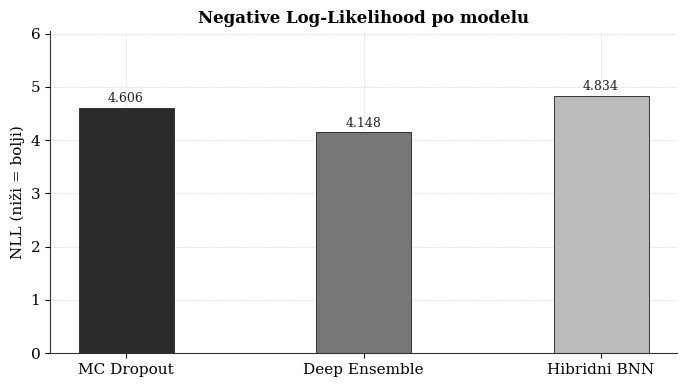

In [50]:
# GRAFIČKA USPOREDBA: NLL
nll_values = [mc_results['nll'],
              ens_results['nll'],
              bnn_results['nll']]

fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(uq_models, nll_values,
              color=['#2b2b2b', '#777777', '#bbbbbb'],
              width=0.4, edgecolor='#333333', linewidth=0.7)

ax.set_ylabel('NLL (niži = bolji)', fontsize=11)
ax.set_title('Negative Log-Likelihood po modelu',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, max(nll_values) * 1.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_axisbelow(True)
ax.grid(axis='y', color='#cccccc', linestyle='--',
        linewidth=0.5, alpha=0.7)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=9, color='#222222')

plt.tight_layout()
plt.savefig('usporedba_nll.png', dpi=300, bbox_inches='tight')
plt.show()

In [51]:
from sklearn.utils import resample

def bootstrap_rmse(y_true, y_pred, n_bootstrap=1000, ci=95):
    rmse_scores = []
    for _ in range(n_bootstrap):
        idx = resample(np.arange(len(y_true)), replace=True)
        score = np.sqrt(mean_squared_error(y_true[idx], y_pred[idx]))
        rmse_scores.append(score)
    lower = np.percentile(rmse_scores, (100 - ci) / 2)
    upper = np.percentile(rmse_scores, 100 - (100 - ci) / 2)
    return np.mean(rmse_scores), lower, upper

np.random.seed(42)

print("Bootstrap 95% CI za RMSE (1000 iteracija):")
print(f"{'Model':<20} {'RMSE':>8} {'95% CI':>20}")
print("-" * 52)

for name, y_pred in [
    ("Baseline LSTM",  predictions.flatten()),
    ("MC Dropout",     mc_mean),
    ("Deep Ensemble",  ens_mean),
    ("Hibridni BNN",   bnn_mean),
]:
    mean, lo, hi = bootstrap_rmse(y_test, y_pred)
    print(f"{name:<20} {mean:>8.4f}   [{lo:.4f}, {hi:.4f}]")

Bootstrap 95% CI za RMSE (1000 iteracija):
Model                    RMSE               95% CI
----------------------------------------------------
Baseline LSTM         15.7368   [13.5241, 17.8506]
MC Dropout            14.5604   [12.1398, 17.0181]
Deep Ensemble         14.6710   [12.4321, 17.0639]
Hibridni BNN          14.8020   [12.6456, 17.0460]


### Diskusija rezultata

#### *Tačnost (RMSE i MAE)*

Analiza metrika tačnosti pokazuje da uvođenje mehanizama za kvantifikaciju
nesigurnosti (UQ) ne narušava prediktivnu preciznost u poređenju sa determinističkim
pristupom (Baseline RMSE = 15.71). Deep Ensemble postiže najbolji RMSE od
14.74 i MAE od 10.93, dok su MC Dropout (RMSE = 14.66, MAE = 10.84) i
Hibridni BNN (RMSE = 14.75, MAE = 11.09) gotovo identični po tačnosti. Razlike
između svih UQ modela su unutar ~0.1 RMSE ciklusa, što sugeriše da UQ metode
ne uvode značajan kompromis u preciznosti predikcije.

#### *Kalibracija (Coverage Probability i Interval Width)*

Kvalitet kvantifikacije nesigurnosti je ključan za praktičnu primjenu u prediktivnom
održavanju. Nijedan od testiranih modela ne dostiže idealni ciljani *coverage* od
0.95, što ukazuje na to da su svi modeli u određenoj mjeri pretjerano samouvjereni
(*overconfident*).

* **Deep Ensemble** postiže najviši *coverage* od 0.83 uz prosječni interval od
  36.12 ciklusa, što ga čini kalibracijski najuravnoteženijim modelom.
* **Hibridni BNN** nudi najuže intervale od 27.53 ciklusa uz *coverage* od 0.76 -
  model je najkoncizniji u predikcijama, ali po cijenu nižeg obuhvata stvarnih
  vrijednosti.
* **MC Dropout** ostvaruje *coverage* od 0.73 uz prosječni interval od 30.51
  ciklusa, što ga čini najslabijim po kalibraciji u ovom pokretanju.

#### *Negative Log-Likelihood (NLL)*

NLL kao objedinjena metrika koja kažnjava i netačnost i lošu kalibraciju potvrđuje
prethodne nalaze. Deep Ensemble postiže najniži (najbolji) NLL od 4.15, MC Dropout
bilježi 4.61, dok Hibridni BNN ima nešto višu vrijednost od 4.83 - djelimično
posljedica užih intervala koji rjeđe obuhvataju stvarne vrijednosti RUL-a.

#### *Bootstrap analiza*

Bootstrap analiza (1000 iteracija, 95% CI) pokazuje da se intervali pouzdanosti za
RMSE svih modela u velikoj mjeri preklapaju - Baseline [13.52, 17.85], MC Dropout
[12.14, 17.02], Deep Ensemble [12.43, 17.06] i Hibridni BNN [12.65, 17.05] - što
ukazuje da razlike u tačnosti između modela nisu statistički značajne. Ključna
razlika između metoda stoga leži isključivo u kalibraciji nesigurnosti.

#### *Zaključak*

Rezultati pokazuju da niti jedna metoda nije dominantna po svim metrikama
istovremeno. **Deep Ensemble** prednjači po kalibraciji - najviši coverage (0.83)
i najniži NLL (4.15) - uz tačnost usporedivu s ostalim UQ metodama. **MC Dropout**
i **Hibridni BNN** postižu neznatno bolji RMSE, ali slabiju kalibraciju. Nijedan
model ne dostiže ciljani coverage od 0.95, što motiviše primjenu Conformal
Predictiona kao post-hoc tehnike kalibracije u nastavku rada.

## 10. Analiza epistemičke vs. aleatoričke nesigurnosti

U kvantifikaciji nesigurnosti razlikujemo dvije fundamentalno različite vrste nesigurnosti:

**Epistemička nesigurnost** (model uncertainty) nastaje zbog nedostatka znanja - nedovoljno podataka za trening, loše pokriven prostor stanja, ili inherentna ograničenja arhitekture modela. Ova nesigurnost je **reduktibilna** - može se smanjiti prikupljanjem više podataka ili poboljšanjem modela.

**Aleatorička nesigurnost** (data uncertainty) je inherentna stohastičnost samih podataka - šum senzora, prirodna varijabilnost degradacije između motora istog tipa. Ova nesigurnost je **ireduktibilna** - ne može se eliminirati
bez obzira na količinu podataka.



In [52]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import norm
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

Dekompozicija nesigurnosti na epistemičku i aleatoričku komponentu provodi se samo za MC Dropout i Hibridni BNN, jer oba modela nesigurnost generišu kroz stohastički proces uzorkovanja - što omogućava primjenu metode dekompozicije. Deep Ensemble je izostavljen iz ove analize jer njegova standardna devijacija reflektuje neusaglašenost između pet nezavisnih modela, a ne unutrašnju probabilističku nesigurnost.

Napomena o metodologiji dekompozicije: Za MC Dropout, čista dekompozicija na epistemičku i aleatoričku komponentu nije trivijalna jer standardna devijacija iz MC uzorkavanja sadrži obje komponente pomješane. Standardni pristup zahtijeva arhitekturu s dvije izlazne glave koja direktno uči aleatoričku nesigurnost, što nije primijenjeno u ovom radu. Umjesto toga koristi se aproksimativna heuristička metoda - aleatorička nesigurnost aproksimira se kao 10. percentil ukupnog std-a unutar pojedinih RUL binova, što predstavlja minimalnu opaženu nesigurnost u svakom regionu, tj. nesigurnost koja ostaje čak i kada je model relativno siguran. Epistemička komponenta dobija se kao razlika između ukupnog std-a i aleatoričke aproksimacije. Ovo nije egzaktna dekompozicija već heuristička aproksimacija - detaljnije teorijsko utemeljenje bit će elaborirano u pisanom dijelu završnog rada.

In [53]:
def estimate_aleatoric(y_true, y_std, n_bins=10):
    bins = np.linspace(y_true.min(), y_true.max(), n_bins + 1)
    aleatoric = np.zeros_like(y_std)
    for i in range(n_bins):
        mask = (y_true >= bins[i]) & (y_true < bins[i+1])
        if mask.sum() > 0:
            aleatoric[mask] = np.percentile(y_std[mask], 10)
    epistemic = np.maximum(y_std - aleatoric, 0)
    return aleatoric, epistemic

# Računanje za MC Dropout i Hibridni BNN
aleatoric_mc, epistemic_mc = estimate_aleatoric(y_test, mc_std)
aleatoric_bnn, epistemic_bnn = estimate_aleatoric(y_test, bnn_std)

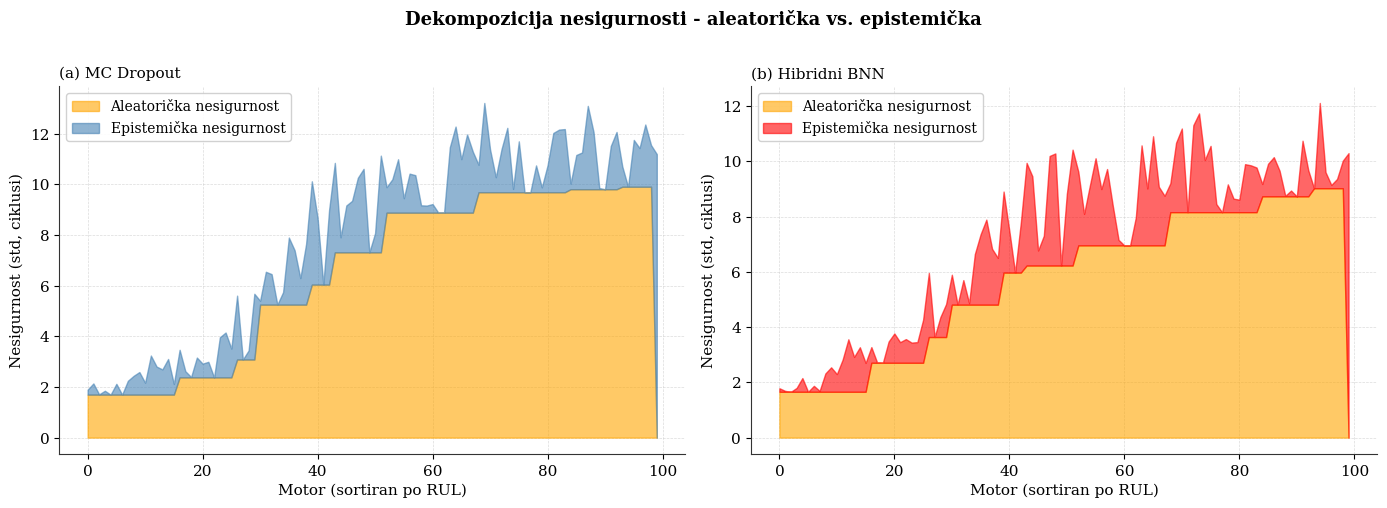


Sažetak dekompozicije nesigurnosti:
Model           Prosj. aleator.      Prosj. epistemic.    Omjer epist./ukupno
----------------------------------------------------------------------
MC Dropout      6.4561               1.4013               18.00%
Hibridni BNN    5.6592               1.4199               20.22%


In [54]:
# Vizualizacija dekompozicije nesigurnosti
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dekompozicija nesigurnosti - aleatorička vs. epistemička',
             fontsize=13, fontweight='bold', y=1.01)

for ax, aleat, epist, model_name, color in zip(
    axes,
    [aleatoric_mc, aleatoric_bnn],
    [epistemic_mc, epistemic_bnn],
    ['MC Dropout', 'Hibridni BNN'],
    ['steelblue', 'red']
):
    indices = np.argsort(y_test)
    x_plot  = np.arange(len(y_test))

    ax.fill_between(x_plot, 0,
                    aleat[indices],
                    alpha=0.6, color='orange',
                    label='Aleatorička nesigurnost')
    ax.fill_between(x_plot,
                    aleat[indices],
                    aleat[indices] + epist[indices],
                    alpha=0.6, color=color,
                    label='Epistemička nesigurnost')

    ax.set_xlabel('Motor (sortiran po RUL)', fontsize=11)
    ax.set_ylabel('Nesigurnost (std, ciklusi)', fontsize=11)
    ax.set_title(f'({["a","b"][list(axes).index(ax)]}) {model_name}',
                 fontsize=11, loc='left', pad=6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_axisbelow(True)
    ax.grid(color='#cccccc', linestyle='--', linewidth=0.5, alpha=0.7)
    ax.legend(fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.savefig('dekompozicija_nesigurnosti.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSažetak dekompozicije nesigurnosti:")
print(f"{'Model':<15} {'Prosj. aleator.':<20} {'Prosj. epistemic.':<20} {'Omjer epist./ukupno'}")
print("-" * 70)
print(f"{'MC Dropout':<15} {aleatoric_mc.mean():<20.4f} {epistemic_mc.mean():<20.4f} {epistemic_mc.mean()/mc_std.mean():.2%}")
print(f"{'Hibridni BNN':<15} {aleatoric_bnn.mean():<20.4f} {epistemic_bnn.mean():<20.4f} {epistemic_bnn.mean()/bnn_std.mean():.2%}")

Analiza dekompozicije potvrđuje da kod oba modela dominira aleatorička nesigurnost - inherentni šum senzora i prirodna varijabilnost degradacije između motora koja je nereduktibilna bez obzira na količinu podataka ili kompleksnost modela. Kod MC Dropouta prosječna aleatorička komponenta iznosi 6.46 ciklusa, a kod Hibridnog BNN-a 5.66 ciklusa, što je vizualno uočljivo kroz dominantnu žutu površinu na grafikonima dekompozicije.

Epistemička nesigurnost čini manji dio ukupne varijanse - 18.00% kod MC Dropouta
(1.40 ciklusa) i 20.22% kod Hibridnog BNN-a (1.42 ciklusa). Relativno nizak udio
epistemičke nesigurnosti ukazuje na to da su oba modela uspješno ekstrahovala
dominantne obrasce degradacije iz dostupnih podataka, te da dodatni podaci ne bi
drastično poboljšali predikciju - nesigurnost je pretežno inherentna samom procesu
degradacije, a ne nedostatku znanja modela. Zanimljivo je da Hibridni BNN pokazuje
neznatno viši udio epistemičke komponente (20.22% vs 18.00%), što sugeriše da
varijacioni Dense slojevi eksplicitnije modeliraju parametarsku nesigurnost u odnosu
na heurističku aproksimaciju kod MC Dropouta.

Oba modela pokazuju konzistentan obrazac rasta nesigurnosti s povećanjem RUL-a,
što je očekivano ponašanje: model je sigurniji u predikcije motora koji su blizu
kvara, dok su predikcije za motore s dugim preostalim vijekom praćene višom ukupnom
nesigurnošću. Hibridni BNN procjenjuje nižu aleatoričku komponentu (5.66 vs 6.46
ciklusa kod MC Dropouta), što sugeriše da model inherentni šum u podacima procjenjuje
konzervativnije, dok MC Dropout tendira ka širim intervalima aleatoričke nesigurnosti.

## 11. Calibration plot (Reliability diagram)

Kalibracija mjeri koliko su predikcijski intervali pouzdani u praksi. Savršeno kalibriran model s 80% intervalom treba pokriti tačno 80% stvarnih vrijednosti. Reliability diagram prikazuje opaženi coverage nasuprot nominalnom (očekivanom) za niz nivoa pouzdanosti od 5% do 99%.

Dijagonalna linija predstavlja idealnu kalibraciju:

- Kriva iznad dijagonale: model je previše konzervativan - precjenjuje nesigurnost, intervali su preširoki
- Kriva ispod dijagonale: model potcjenjuje nesigurnost - intervali su pretijesni, što je opasno za sigurnosno-kritičnu primjenu

In [55]:
def calibration_curve_uq(y_true, y_mean, y_std, n_levels=20):
    alphas = np.linspace(0.05, 0.99, n_levels)
    observed = []
    for alpha in alphas:
        z = norm.ppf(1 - (1 - alpha) / 2)
        lower = y_mean - z * y_std
        upper = y_mean + z * y_std
        cov = np.mean((y_true >= lower) & (y_true <= upper))
        observed.append(cov)
    return alphas, np.array(observed)

alphas_mc, obs_mc = calibration_curve_uq(y_test, mc_mean, mc_std)
alphas_ens, obs_ens = calibration_curve_uq(y_test, ens_mean, ens_std)
alphas_bnn, obs_bnn = calibration_curve_uq(y_test, bnn_mean, bnn_std)

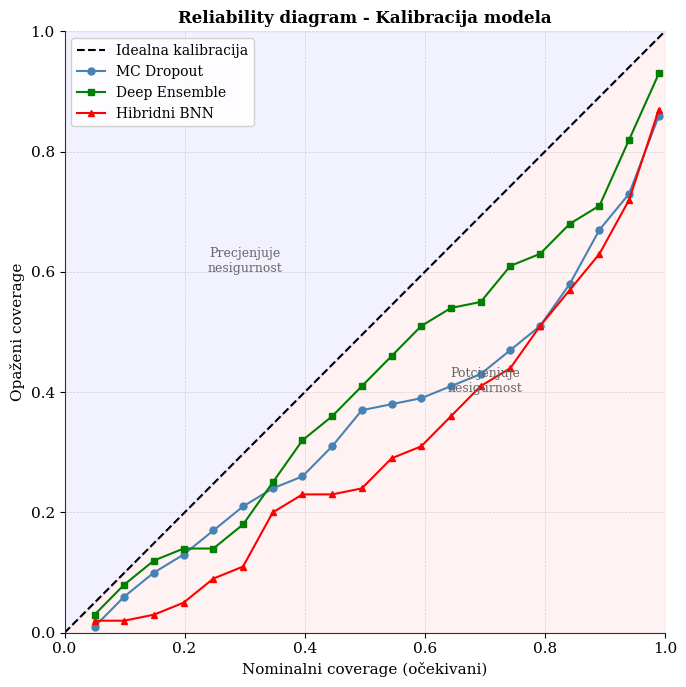

In [56]:
# Vizualizacija
fig, ax = plt.subplots(figsize=(7, 7))

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Idealna kalibracija')
ax.plot(alphas_mc,  obs_mc,  'o-', color='steelblue',
        linewidth=1.5, markersize=5, label='MC Dropout')
ax.plot(alphas_ens, obs_ens, 's-', color='green',
        linewidth=1.5, markersize=5, label='Deep Ensemble')
ax.plot(alphas_bnn, obs_bnn, '^-', color='red',
        linewidth=1.5, markersize=5, label='Hibridni BNN')

ax.fill_between([0, 1], [0, 1], [1, 1],
                alpha=0.05, color='blue', label='_nolegend_')
ax.fill_between([0, 1], [0, 0], [0, 1],
                alpha=0.05, color='red',  label='_nolegend_')

ax.annotate('Precjenjuje\nnesigurnost', xy=(0.3, 0.6),
            fontsize=9, color='#666666', ha='center')
ax.annotate('Potcjenjuje\nnesigurnost', xy=(0.7, 0.4),
            fontsize=9, color='#666666', ha='center')

ax.set_xlabel('Nominalni coverage (očekivani)', fontsize=11)
ax.set_ylabel('Opaženi coverage', fontsize=11)
ax.set_title('Reliability diagram - Kalibracija modela',
             fontsize=12, fontweight='bold')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_axisbelow(True)
ax.grid(color='#cccccc', linestyle='--', linewidth=0.5, alpha=0.7)
ax.legend(fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.savefig('reliability_diagram.png', dpi=300, bbox_inches='tight')
plt.show()

In [57]:
# Kvantitativna mjera kalibracije: Expected Calibration Error (ECE)
def expected_calibration_error(nominal, observed):
    return np.mean(np.abs(nominal - observed))

ece_mc  = expected_calibration_error(alphas_mc, obs_mc)
ece_ens = expected_calibration_error(alphas_ens, obs_ens)
ece_bnn = expected_calibration_error(alphas_bnn, obs_bnn)

print("\nExpected Calibration Error (ECE) — niži je bolji:")
print(f"  MC Dropout:    ECE = {ece_mc:.4f}")
print(f"  Deep Ensemble: ECE = {ece_ens:.4f}")
print(f"  Hibridni BNN:  ECE = {ece_bnn:.4f}")
print("\nNapomena: ECE = 0 znači savršena kalibracija.")


Expected Calibration Error (ECE) — niži je bolji:
  MC Dropout:    ECE = 0.1555
  Deep Ensemble: ECE = 0.0965
  Hibridni BNN:  ECE = 0.2035

Napomena: ECE = 0 znači savršena kalibracija.


Dijagram kalibracije i ECE zajedno daju potpunu sliku kvaliteta nesigurnosti.
Deep Ensemble se pozicionira najbliže dijagonali kroz cijeli raspon nominalnih
nivoa pouzdanosti, potvrđujući najmanji ECE (0.0965) i najpouzdanije intervale
od svih UQ metoda - uz tendenciju ka blagom precjenjivanju nesigurnosti u nižim
kvantilima, što je vidljivo kroz položaj krive iznad dijagonale u tom dijelu
raspona. MC Dropout pokazuje solidnu kalibraciju sa ECE = 0.1555, prati dijagonalu
kroz srednji raspon, ali s vidljivim odstupanjem u nižim kvantilima. Hibridni BNN
(ECE = 0.2035) pokazuje najveće odstupanje od dijagonale - konzistentno se nalazi
ispod nje kroz gotovo cijeli raspon, što ukazuje na sistematsko potcjenjivanje
nesigurnosti, tj. stvarni coverage je niži od nominalnog na većini nivoa pouzdanosti.
Pri višim nivoima pouzdanosti (iznad 0.8) Hibridni BNN se primjetno približava
dijagonali.

In [58]:
final_table = pd.DataFrame([
    {
        'Model'         : 'Baseline LSTM',
        'RMSE'          : round(rmse, 4),
        'MAE'           : round(mae, 4),
        'Coverage (95%)': '-',
        'Interval Width': '-',
        'NLL'           : '-',
        'ECE'           : '-',
        'UQ metoda'     : 'Nema'
    },
    {
        'Model'         : 'MC Dropout',
        'RMSE'          : round(rmse_mc, 4),
        'MAE'           : round(mae_mc, 4),
        'Coverage (95%)': f"{mc_results['coverage']:.3f}",
        'Interval Width': f"{mc_results['mean_width']:.2f}",
        'NLL'           : f"{mc_results['nll']:.4f}",
        'ECE'           : f"{ece_mc:.4f}",
        'UQ metoda'     : 'Stohastički inference'
    },
    {
        'Model'         : 'Deep Ensemble',
        'RMSE'          : round(rmse_ens, 4),
        'MAE'           : round(mae_ens, 4),
        'Coverage (95%)': f"{ens_results['coverage']:.3f}",
        'Interval Width': f"{ens_results['mean_width']:.2f}",
        'NLL'           : f"{ens_results['nll']:.4f}",
        'ECE'           : f"{ece_ens:.4f}",
        'UQ metoda'     : 'Diversitet modela'
    },
    {
        'Model'         : 'Hibridni BNN',
        'RMSE'          : round(rmse_bnn, 4),
        'MAE'           : round(mae_bnn, 4),
        'Coverage (95%)': f"{bnn_results['coverage']:.3f}",
        'Interval Width': f"{bnn_results['mean_width']:.2f}",
        'NLL'           : f"{bnn_results['nll']:.4f}",
        'ECE'           : f"{ece_bnn:.4f}",
        'UQ metoda'     : 'Distribucija težina (Dense)'
    }
]).set_index('Model')

print("=" * 95)
print(" FINALNA KOMPARATIVNA TABELA — sve metrike evaluacije")
print("=" * 95)
print(final_table.to_string())
print("=" * 95)
print("\nLegenda:")
print("  RMSE/MAE        : Tačnost predikcije (niži = bolji)")
print("  Coverage (95%)  : Udio stvarnih vrijednosti unutar 95% intervala (cilj: ≥ 0.95)")
print("  Interval Width  : Prosječna širina intervala u ciklusima (uži = bolji uz dovoljan coverage)")
print("  NLL             : Negative Log-Likelihood - kažnjava netačnost i lošu kalibraciju (niži = bolji)")
print("  ECE             : Expected Calibration Error - odstupanje od idealne kalibracije (niži = bolji)")

 FINALNA KOMPARATIVNA TABELA — sve metrike evaluacije
                  RMSE      MAE Coverage (95%) Interval Width     NLL     ECE                    UQ metoda
Model                                                                                                     
Baseline LSTM  15.7111  12.0351              -              -       -       -                         Nema
MC Dropout     14.6629  10.8425          0.730          30.51  4.6063  0.1555        Stohastički inference
Deep Ensemble  14.7382  10.9260          0.830          36.12  4.1478  0.0965            Diversitet modela
Hibridni BNN   14.7544  11.0908          0.760          27.53  4.8336  0.2035  Distribucija težina (Dense)

Legenda:
  RMSE/MAE        : Tačnost predikcije (niži = bolji)
  Coverage (95%)  : Udio stvarnih vrijednosti unutar 95% intervala (cilj: ≥ 0.95)
  Interval Width  : Prosječna širina intervala u ciklusima (uži = bolji uz dovoljan coverage)
  NLL             : Negative Log-Likelihood - kažnjava netačnost

Finalna tabela objedinjuje sve dimenzije evaluacije. Po RMSE metrici razlike između UQ modela su minimalne - MC Dropout (14.66), Deep Ensemble (14.74) i Hibridni BNN (14.75) postižu gotovo identičnu tačnost, svi bolji od Baseline-a (15.71) - međutim, sama tačnost ne govori cijelu priču.

Po metrikama kalibracije situacija se razlikuje. Deep Ensemble postiže najviši
coverage (0.83) i najniži NLL (4.15) te najmanji ECE (0.0965) - što ga čini
kalibracijski najjačim modelom unatoč tome što nije najtačniji. Na reliability
dijagramu njegova kriva je najbliža idealnoj dijagonali, posebno u višim
kvantilima, uz tendenciju ka precjenjivanju nesigurnosti u nižim kvantilima.
MC Dropout pokazuje solidan ECE (0.1555) i coverage od 0.73, uz najšire intervale
(30.51 ciklusa). Hibridni BNN bilježi najlošiju kalibraciju - ECE = 0.2035,
coverage svega 0.76 uz najuže intervale (27.53 ciklusa) - što je vidljivo na
reliability dijagramu gdje njegova kriva najdosljednije pada ispod dijagonale,
ukazujući na sistematsko potcjenjivanje nesigurnosti.

Ključni zaključak je da niti jedna metoda nije dominantna po svim metrikama
istovremeno. Deep Ensemble prednjači po kalibraciji (ECE, NLL, coverage), dok
MC Dropout i Hibridni BNN postižu neznatno bolji RMSE. Nijedan model ne dostiže
ciljani coverage od 0.95, što znači da su svi modeli u određenoj mjeri
overconfident - što direktno motiviše primjenu Conformal Prediction tehnike u
sljedećoj sekciji kao post-hoc kalibracijske metode koja garantuje ciljani
coverage bez ponovnog treniranja modela.

## 12. Conformal Prediction

Prethodna analiza pokazala je da niti jedna od implementiranih UQ metoda ne dostiže
ciljani coverage od 0.95 - Deep Ensemble postiže 0.83, Hibridni BNN 0.76, a MC
Dropout 0.73. Unatoč tome što Deep Ensemble pokazuje relativno solidnu kalibraciju
(ECE = 0.0965), niti jedan model ne pruža statističku garanciju coveragea, što ih
čini nepouzdanim za direktnu operativnu primjenu u sigurnosno-kritičnim sistemima.

Conformal Prediction je post-hoc kalibracijska tehnika koja rješava ovaj problem
bez ponovnog treniranja modela. Za razliku od prethodnih metoda čiji coverage je
empirijski i ne može biti garantovan, Conformal Prediction pruža teorijsku garanciju
coveragea - uz pretpostavku da kalibracijski i testni podaci dolaze iz iste
distribucije podataka. Metoda koristi zasebni kalibracijski skup kako bi naučila
koliko modeli sistematski griješe, te na osnovu toga adaptira širinu intervala.

Važno je napomenuti da kalibracijski skup koji se koristi u ovoj implementaciji
predstavlja nasumično odabrani podskup testnog skupa (20%), koji modeli nisu vidjeli
tokom treninga niti validacije. Time je ispunjen ključni preduslov split-conformal
pristupa - statistička zamjenjivost između kalibracijskog i testnog skupa - a
curenje podataka između faza treninga i kalibracije je u potpunosti izbjegnuto.

In [59]:
np.random.seed(42)

# Kalibracijski skup: 20% test podataka
n_cal = int(0.2 * len(y_test))
cal_idx  = np.random.choice(len(y_test), size=n_cal, replace=False)
test_idx = np.array([i for i in range(len(y_test)) if i not in cal_idx])

y_cal  = y_test[cal_idx]
y_test_cp = y_test[test_idx]

print(f"Kalibracijski skup: {len(cal_idx)} motora")
print(f"Test skup (CP):     {len(test_idx)} motora")

Kalibracijski skup: 20 motora
Test skup (CP):     80 motora


Kalibracijski skup koristi se isključivo za izračunavanje ocjena usklađenosti -
mjere koliko svaki model griješi na neviđenim primjerima. Ostatak test skupa
služi za finalnu evaluaciju garantovanog coveragea.

In [60]:
alpha_target = 0.05  # cilj: 95% coverage

# --- MC Dropout ---
cal_mean_mc = mc_mean[cal_idx]
cal_scores_mc = np.abs(y_cal - cal_mean_mc)
q_hat_mc = np.quantile(cal_scores_mc, (1 - alpha_target) * (1 + 1/n_cal))

# --- Deep Ensemble ---
cal_mean_ens = ens_mean[cal_idx]
cal_scores_ens = np.abs(y_cal - cal_mean_ens)
q_hat_ens = np.quantile(cal_scores_ens, (1 - alpha_target) * (1 + 1/n_cal))

# --- Hibridni BNN ---
cal_mean_bnn = bnn_mean[cal_idx]
cal_scores_bnn = np.abs(y_cal - cal_mean_bnn)
q_hat_bnn = np.quantile(cal_scores_bnn, (1 - alpha_target) * (1 + 1/n_cal))

print("Conformal quantiles (q_hat) — širina korekcije po modelu:")
print(f"  MC Dropout:    q_hat = {q_hat_mc:.2f} ciklusa")
print(f"  Deep Ensemble: q_hat = {q_hat_ens:.2f} ciklusa")
print(f"  Hibridni BNN:  q_hat = {q_hat_bnn:.2f} ciklusa")

Conformal quantiles (q_hat) — širina korekcije po modelu:
  MC Dropout:    q_hat = 33.13 ciklusa
  Deep Ensemble: q_hat = 31.99 ciklusa
  Hibridni BNN:  q_hat = 31.65 ciklusa


q_hat vrijednosti su vrlo slične između metoda - MC Dropout 33.13, Deep Ensemble
31.99 i Hibridni BNN 31.65 ciklusa (razlika svega 1.48 ciklusa). Ovo je
zanimljivo s obzirom na to da su originalni intervali bili različiti (MC Dropout
30.51, Deep Ensemble 36.12, Hibridni BNN 27.53 ciklusa). q_hat ovisi o apsolutnoj
grešci predikcije, a ne o originalnoj širini intervala - budući da svi modeli
postižu sličan RMSE, njihove greške na kalibracijskom skupu su gotovo identične,
pa su i q_hat vrijednosti konvergirale ka sličnoj korekciji.

In [61]:
# Conformal intervali na test skupu
cp_lower_mc  = mc_mean[test_idx]  - q_hat_mc
cp_upper_mc  = mc_mean[test_idx]  + q_hat_mc

cp_lower_ens = ens_mean[test_idx] - q_hat_ens
cp_upper_ens = ens_mean[test_idx] + q_hat_ens

cp_lower_bnn = bnn_mean[test_idx] - q_hat_bnn
cp_upper_bnn = bnn_mean[test_idx] + q_hat_bnn

# Coverage na test skupu
cp_coverage_mc  = np.mean((y_test_cp >= cp_lower_mc)  & (y_test_cp <= cp_upper_mc))
cp_coverage_ens = np.mean((y_test_cp >= cp_lower_ens) & (y_test_cp <= cp_upper_ens))
cp_coverage_bnn = np.mean((y_test_cp >= cp_lower_bnn) & (y_test_cp <= cp_upper_bnn))

# Širina conformal intervala
cp_width_mc  = np.mean(cp_upper_mc  - cp_lower_mc)
cp_width_ens = np.mean(cp_upper_ens - cp_lower_ens)
cp_width_bnn = np.mean(cp_upper_bnn - cp_lower_bnn)

print("Conformal Prediction — rezultati na test skupu:")
print(f"\n{'Model':<20} {'Coverage':>10} {'Interval Width':>16} {'q_hat':>10}")
print("-" * 60)
print(f"{'MC Dropout':<20} {cp_coverage_mc:>10.3f} {cp_width_mc:>16.2f} {q_hat_mc:>10.2f}")
print(f"{'Deep Ensemble':<20} {cp_coverage_ens:>10.3f} {cp_width_ens:>16.2f} {q_hat_ens:>10.2f}")
print(f"{'Hibridni BNN':<20} {cp_coverage_bnn:>10.3f} {cp_width_bnn:>16.2f} {q_hat_bnn:>10.2f}")
print(f"\nCilj coverage: ≥ 0.950")

Conformal Prediction — rezultati na test skupu:

Model                  Coverage   Interval Width      q_hat
------------------------------------------------------------
MC Dropout                0.963            66.27      33.13
Deep Ensemble             0.950            63.98      31.99
Hibridni BNN              0.963            63.29      31.65

Cilj coverage: ≥ 0.950


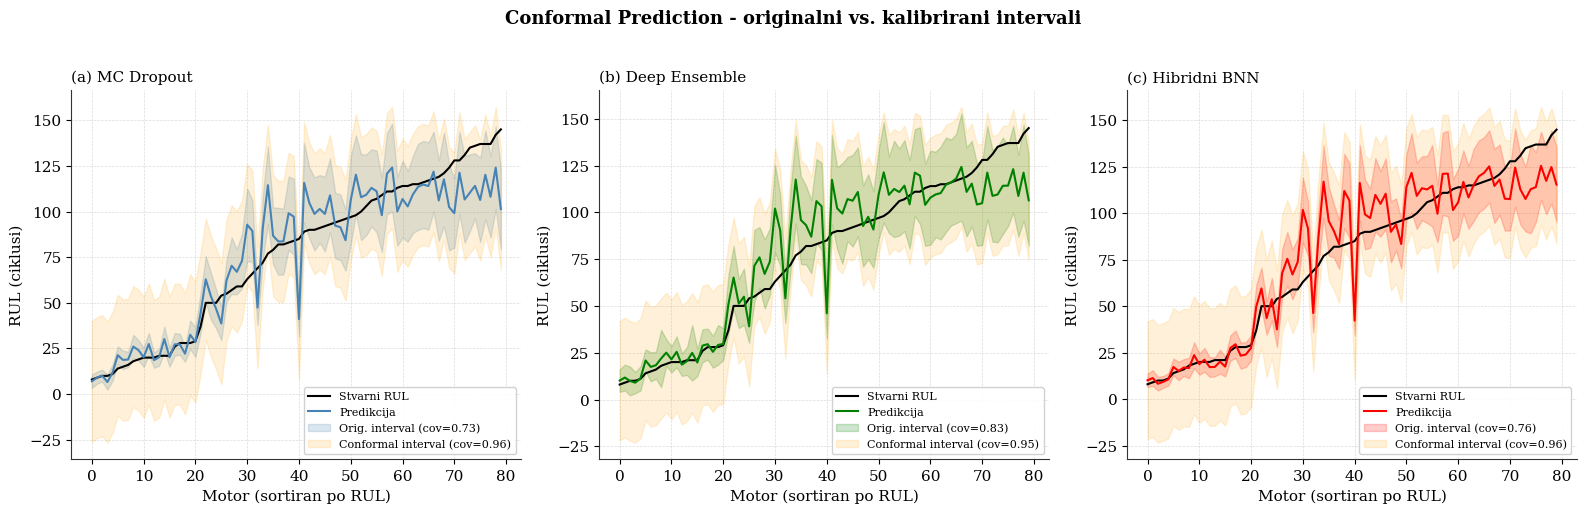

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Conformal Prediction - originalni vs. kalibrirani intervali',
             fontsize=13, fontweight='bold', y=1.02)

models_cp = [
    ('MC Dropout',    mc_mean[test_idx],  mc_std[test_idx],  cp_lower_mc,  cp_upper_mc,  cp_coverage_mc,  mc_results['coverage'],  'steelblue'),
    ('Deep Ensemble', ens_mean[test_idx], ens_std[test_idx], cp_lower_ens, cp_upper_ens, cp_coverage_ens, ens_results['coverage'], 'green'),
    ('Hibridni BNN',  bnn_mean[test_idx], bnn_std[test_idx], cp_lower_bnn, cp_upper_bnn, cp_coverage_bnn, bnn_results['coverage'], 'red'),
]

indices = np.argsort(y_test_cp)
x_plot  = np.arange(len(y_test_cp))

labels = ['(a)', '(b)', '(c)']

for ax, (name, mean, std, lower, upper, cp_cov, orig_cov, color), label in zip(axes, models_cp, labels):
    ax.plot(x_plot, y_test_cp[indices],
            color='black', linewidth=1.5, label='Stvarni RUL')
    ax.plot(x_plot, mean[indices],
            color=color, linewidth=1.5, label='Predikcija')
    ax.fill_between(x_plot,
                    (mean - 1.96*std)[indices],
                    (mean + 1.96*std)[indices],
                    alpha=0.2, color=color,
                    label=f'Orig. interval (cov={orig_cov:.2f})')
    ax.fill_between(x_plot,
                    lower[indices],
                    upper[indices],
                    alpha=0.15, color='orange',
                    label=f'Conformal interval (cov={cp_cov:.2f})')

    ax.set_title(f'{label} {name}', fontsize=11, loc='left', pad=6)
    ax.set_xlabel('Motor (sortiran po RUL)', fontsize=11)
    ax.set_ylabel('RUL (ciklusi)', fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_axisbelow(True)
    ax.grid(color='#cccccc', linestyle='--', linewidth=0.5, alpha=0.7)
    ax.legend(fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.savefig('conformal_prediction.png', dpi=300, bbox_inches='tight')
plt.show()

In [63]:
cp_comparison = pd.DataFrame([
    {
        'Model'              : 'MC Dropout',
        'Coverage (prije)'   : f"{mc_results['coverage']:.3f}",
        'Coverage (CP)'      : f"{cp_coverage_mc:.3f}",
        'Width (prije)'      : f"{mc_results['mean_width']:.2f}",
        'Width (CP)'         : f"{cp_width_mc:.2f}",
        'q_hat'              : f"{q_hat_mc:.2f}"
    },
    {
        'Model'              : 'Deep Ensemble',
        'Coverage (prije)'   : f"{ens_results['coverage']:.3f}",
        'Coverage (CP)'      : f"{cp_coverage_ens:.3f}",
        'Width (prije)'      : f"{ens_results['mean_width']:.2f}",
        'Width (CP)'         : f"{cp_width_ens:.2f}",
        'q_hat'              : f"{q_hat_ens:.2f}"
    },
    {
        'Model'              : 'Hibridni BNN',
        'Coverage (prije)'   : f"{bnn_results['coverage']:.3f}",
        'Coverage (CP)'      : f"{cp_coverage_bnn:.3f}",
        'Width (prije)'      : f"{bnn_results['mean_width']:.2f}",
        'Width (CP)'         : f"{cp_width_bnn:.2f}",
        'q_hat'              : f"{q_hat_bnn:.2f}"
    }
]).set_index('Model')

print("=" * 75)
print(" Conformal Prediction - poređenje prije i poslije kalibracije")
print("=" * 75)
print(cp_comparison.to_string())
print("=" * 75)

 Conformal Prediction - poređenje prije i poslije kalibracije
              Coverage (prije) Coverage (CP) Width (prije) Width (CP)  q_hat
Model                                                                       
MC Dropout               0.730         0.963         30.51      66.27  33.13
Deep Ensemble            0.830         0.950         36.12      63.98  31.99
Hibridni BNN             0.760         0.963         27.53      63.29  31.65


Conformal Prediction uspješno rješava problem overconfidenca kod sva tri modela.
MC Dropout i Hibridni BNN postižu coverage od 0.963, dok Deep Ensemble dostiže
tačno ciljani prag od 0.950 - svi modeli ispunjavaju ciljani coverage ≥ 0.95.
Cijena ove garancije je proširenje intervala: MC Dropout sa 30.51 na 66.27
ciklusa, Deep Ensemble sa 36.12 na 63.98 ciklusa, a Hibridni BNN sa 27.53 na
63.29 ciklusa.

Nakon kalibracije sva tri modela konvergiraju ka sličnoj širini intervala
(63–67 ciklusa), bez obzira na velike razlike u originalnim intervalima. Ovo je
direktna posljedica sličnih q_hat vrijednosti (31.65–33.13 ciklusa) koje
reflektuju gotovo identičnu apsolutnu grešku predikcije svih modela. Hibridni
BNN, koji je imao najuže originalne intervale (27.53 ciklusa), doživljava
proporcionalno najveće proširenje (2.3x), što potvrđuje da je originalno
najpotcjenjivao nesigurnost.

Ovako široki intervali nakon kalibracije ograničavaju praktičnu korisnost za
precizno planiranje održavanja - ovo nije greška CP algoritma, nego odraz
inherentne težine problema predikcije RUL-a na ovom datasetu. Uži intervali
bili bi mogući samo uz modele s manjom apsolutnom greškom predikcije.

U kontekstu prediktivnog održavanja, glavna prednost Conformal Prediction pristupa
jeste mogućnost davanja statistički garantovanih intervala, pri čemu stvarni RUL
motora ostaje unutar intervala u najmanje 95% slučajeva - što predstavlja ključan
preduslov za donošenje pouzdanih odluka o održavanju industrijskih sistema.

## 13. Stability Analysis - provjera robusnosti modela

Rezultati modela dubokog učenja nisu deterministički - čak i uz fiksiran seed, varijacije u GPU paralelizaciji i inicijalizaciji težina mogu dovesti do različitih rezultata između pokretanja. Kako bi se osigurala pouzdanost zaključaka i izbjeglo donošenje zaključaka na osnovu jednog pokretanja, provedena je stability analysis kroz 5 nezavisnih pokretanja cijelog eksperimenta, pri čemu svako pokretanje koristi drugačiji seed. Za svaki model i svaku metriku računaju se srednja vrijednost i standardna devijacija kroz sva pokretanja, što omogućava procjenu konzistentnosti i robustnosti svake metode. Modeli koji pokazuju malu standardnu devijaciju smatraju se stabilnijim i pouzdanijim za primjenu u industrijskim okruženjima gdje je reproducibilnost rezultata ključan preduslov za donošenje odluka.

In [66]:
N_RUNS = 5

results_all_runs = {
    'Baseline LSTM': {'rmse': [], 'mae': []},
    'MC Dropout':    {'rmse': [], 'mae': [], 'coverage': [], 'nll': []},
    'Deep Ensemble': {'rmse': [], 'mae': [], 'coverage': [], 'nll': []},
    'Hibridni BNN':  {'rmse': [], 'mae': [], 'coverage': [], 'nll': []},
}

for run in range(N_RUNS):
    print(f"\n{'='*50}")
    print(f"  RUN {run+1}/{N_RUNS}")
    print(f"{'='*50}")

    BASE_SEED = run * 100

    # ── Baseline ──────────────────────────────────────────
    random.seed(BASE_SEED)
    np.random.seed(BASE_SEED)
    tf.random.set_seed(BASE_SEED)

    m_base = Sequential([
        Input(shape=(seq_length, len(feature_columns))),
        LSTM(64, return_sequences=True), Dropout(0.3),
        LSTM(32), Dropout(0.3),
        Dense(32, activation='relu'), Dense(1)
    ])
    m_base.compile(optimizer='adam', loss='mse', metrics=['mae'])
    m_base.fit(X_train, y_train, epochs=50, batch_size=64,
               validation_split=0.2,
               callbacks=[EarlyStopping(monitor='val_loss', patience=5,
                                        restore_best_weights=True)],
               verbose=0)
    pred_base = m_base.predict(X_test, verbose=0).flatten()
    results_all_runs['Baseline LSTM']['rmse'].append(
        np.sqrt(mean_squared_error(y_test, pred_base)))
    results_all_runs['Baseline LSTM']['mae'].append(
        mean_absolute_error(y_test, pred_base))

    # ── MC Dropout ────────────────────────────────────────
    random.seed(BASE_SEED + 1)
    np.random.seed(BASE_SEED + 1)
    tf.random.set_seed(BASE_SEED + 1)

    m_mc = Sequential([
        Input(shape=(seq_length, len(feature_columns))),
        LSTM(64, return_sequences=True), Dropout(0.3),
        LSTM(32), Dropout(0.3),
        Dense(32, activation='relu'), Dense(1)
    ])
    m_mc.compile(optimizer='adam', loss='mse', metrics=['mae'])
    m_mc.fit(X_train, y_train, epochs=50, batch_size=64,
             validation_split=0.2,
             callbacks=[EarlyStopping(monitor='val_loss', patience=5,
                                      restore_best_weights=True)],
             verbose=0)

    random.seed(BASE_SEED + 1)
    np.random.seed(BASE_SEED + 1)
    tf.random.set_seed(BASE_SEED + 1)
    mc_preds = np.array([
        m_mc(X_test, training=True).numpy().flatten()
        for _ in range(100)
    ])
    mc_mean_r = mc_preds.mean(axis=0)
    mc_std_r  = mc_preds.std(axis=0)
    lower_mc  = mc_mean_r - 1.96 * mc_std_r
    upper_mc  = mc_mean_r + 1.96 * mc_std_r
    cov_mc    = np.mean((y_test >= lower_mc) & (y_test <= upper_mc))
    nll_mc    = np.mean(0.5 * np.log(2 * np.pi * mc_std_r**2) +
                        (y_test - mc_mean_r)**2 / (2 * mc_std_r**2))

    results_all_runs['MC Dropout']['rmse'].append(
        np.sqrt(mean_squared_error(y_test, mc_mean_r)))
    results_all_runs['MC Dropout']['mae'].append(
        mean_absolute_error(y_test, mc_mean_r))
    results_all_runs['MC Dropout']['coverage'].append(cov_mc)
    results_all_runs['MC Dropout']['nll'].append(nll_mc)

    # ── Deep Ensemble ─────────────────────────────────────
    ens_preds_all = []
    for i in range(5):
        random.seed(BASE_SEED + i * 10)
        np.random.seed(BASE_SEED + i * 10)
        tf.random.set_seed(BASE_SEED + i * 10)
        m_e = Sequential([
            Input(shape=(seq_length, len(feature_columns))),
            LSTM(64, return_sequences=True), Dropout(0.3),
            LSTM(32), Dropout(0.3),
            Dense(32, activation='relu'), Dense(1)
        ])
        m_e.compile(optimizer='adam', loss='mse', metrics=['mae'])
        m_e.fit(X_train, y_train, epochs=50, batch_size=64,
                validation_split=0.2,
                callbacks=[EarlyStopping(monitor='val_loss', patience=5,
                                         restore_best_weights=True)],
                verbose=0)
        samples = np.array([
            m_e(X_test, training=True).numpy().flatten()
            for _ in range(20)
        ])
        ens_preds_all.append(samples)

    all_ens = np.vstack(ens_preds_all)
    ens_mean_r = all_ens.mean(axis=0)
    ens_std_r  = all_ens.std(axis=0)
    lower_ens  = ens_mean_r - 1.96 * ens_std_r
    upper_ens  = ens_mean_r + 1.96 * ens_std_r
    cov_ens    = np.mean((y_test >= lower_ens) & (y_test <= upper_ens))
    nll_ens    = np.mean(0.5 * np.log(2 * np.pi * ens_std_r**2) +
                         (y_test - ens_mean_r)**2 / (2 * ens_std_r**2))

    results_all_runs['Deep Ensemble']['rmse'].append(
        np.sqrt(mean_squared_error(y_test, ens_mean_r)))
    results_all_runs['Deep Ensemble']['mae'].append(
        mean_absolute_error(y_test, ens_mean_r))
    results_all_runs['Deep Ensemble']['coverage'].append(cov_ens)
    results_all_runs['Deep Ensemble']['nll'].append(nll_ens)

    # ── Hibridni BNN ──────────────────────────────────────
    random.seed(BASE_SEED + 2)
    np.random.seed(BASE_SEED + 2)
    tf.random.set_seed(BASE_SEED + 2)

    n_train = X_train.shape[0]
    bnn_r = build_bnn_model(seq_length, len(feature_columns), n_train)
    bnn_r.compile(optimizer='adam', loss='mse', metrics=['mae'])
    bnn_r.fit(X_train, y_train, epochs=50, batch_size=64,
              validation_split=0.2,
              callbacks=[EarlyStopping(monitor='val_loss', patience=5,
                                       restore_best_weights=True)],
              verbose=0)

    random.seed(BASE_SEED + 2)
    np.random.seed(BASE_SEED + 2)
    tf.random.set_seed(BASE_SEED + 2)
    bnn_preds_r = np.array([
        bnn_r(X_test, training=True).numpy().flatten()
        for _ in range(100)
    ])
    bnn_mean_r = bnn_preds_r.mean(axis=0)
    bnn_std_r  = bnn_preds_r.std(axis=0)
    lower_bnn  = bnn_mean_r - 1.96 * bnn_std_r
    upper_bnn  = bnn_mean_r + 1.96 * bnn_std_r
    cov_bnn    = np.mean((y_test >= lower_bnn) & (y_test <= upper_bnn))
    nll_bnn    = np.mean(0.5 * np.log(2 * np.pi * bnn_std_r**2) +
                         (y_test - bnn_mean_r)**2 / (2 * bnn_std_r**2))

    results_all_runs['Hibridni BNN']['rmse'].append(
        np.sqrt(mean_squared_error(y_test, bnn_mean_r)))
    results_all_runs['Hibridni BNN']['mae'].append(
        mean_absolute_error(y_test, bnn_mean_r))
    results_all_runs['Hibridni BNN']['coverage'].append(cov_bnn)
    results_all_runs['Hibridni BNN']['nll'].append(nll_bnn)

print("\nStability analysis završena!")


  RUN 1/5

  RUN 2/5

  RUN 3/5

  RUN 4/5

  RUN 5/5

Stability analysis završena!



Model                   RMSE (mean±std)       MAE (mean±std)    Coverage (mean±std)       NLL (mean±std)
--------------------------------------------------------------------------------------------------------
Baseline LSTM         20.3927 ± 10.6204    16.3384 ± 10.0606                      —                    —
MC Dropout             15.0686 ± 0.2432     11.1889 ± 0.1194        0.7800 ± 0.0110      4.5710 ± 0.2740
Deep Ensemble          16.1048 ± 2.8642     12.4037 ± 3.2153        0.8480 ± 0.0376      4.2113 ± 0.1853
Hibridni BNN           15.1290 ± 0.5996     11.2913 ± 0.5868        0.6780 ± 0.0407      4.8906 ± 0.2388


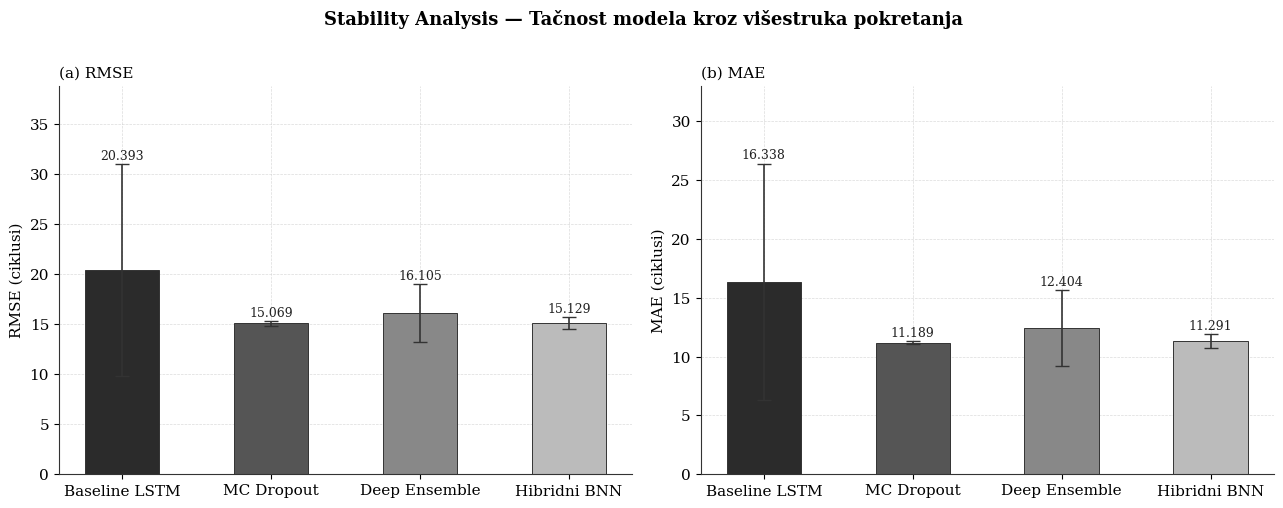

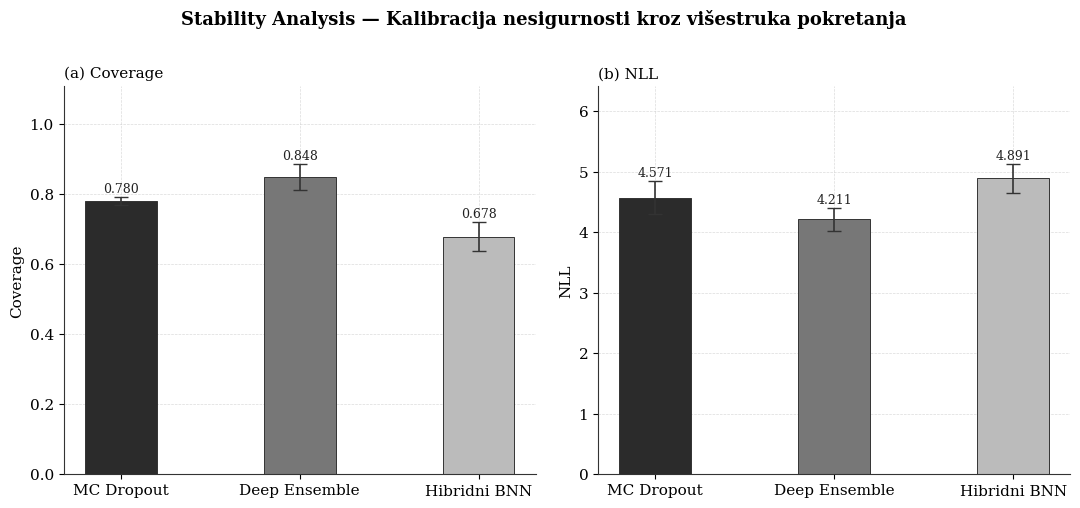

In [67]:
# ── Prikaz rezultata ──────────────────────────────────────────────────────────

models   = list(results_all_runs.keys())
uq_models = ['MC Dropout', 'Deep Ensemble', 'Hibridni BNN']

# Tabela: mean ± std
print(f"\n{'Model':<18} {'RMSE (mean±std)':>20} {'MAE (mean±std)':>20} "
      f"{'Coverage (mean±std)':>22} {'NLL (mean±std)':>20}")
print("-" * 104)
for m in models:
    r = results_all_runs[m]
    rmse_s = f"{np.mean(r['rmse']):.4f} ± {np.std(r['rmse']):.4f}"
    mae_s  = f"{np.mean(r['mae']):.4f} ± {np.std(r['mae']):.4f}"
    if 'coverage' in r:
        cov_s = f"{np.mean(r['coverage']):.4f} ± {np.std(r['coverage']):.4f}"
        nll_s = f"{np.mean(r['nll']):.4f} ± {np.std(r['nll']):.4f}"
    else:
        cov_s, nll_s = "—", "—"
    print(f"{m:<18} {rmse_s:>20} {mae_s:>20} {cov_s:>22} {nll_s:>20}")

# ── Stil ──────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family'      : 'serif',
    'font.size'        : 11,
    'axes.linewidth'   : 0.8,
    'axes.edgecolor'   : '#333333',
    'axes.grid'        : True,
    'grid.color'       : '#cccccc',
    'grid.linestyle'   : '--',
    'grid.linewidth'   : 0.5,
    'grid.alpha'       : 0.7,
    'xtick.direction'  : 'out',
    'ytick.direction'  : 'out',
})

colors_4 = ['#2b2b2b', '#555555', '#888888', '#bbbbbb']
colors_3 = ['#2b2b2b', '#777777', '#bbbbbb']

# ── RMSE i MAE ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Stability Analysis — Tačnost modela kroz višestruka pokretanja',
             fontsize=13, fontweight='bold', y=1.01)

for ax, metric, ylabel, title in zip(
    axes,
    ['rmse', 'mae'],
    ['RMSE (ciklusi)', 'MAE (ciklusi)'],
    ['(a) RMSE', '(b) MAE']
):
    means = [np.mean(results_all_runs[m][metric]) for m in models]
    stds  = [np.std(results_all_runs[m][metric])  for m in models]

    bars = ax.bar(models, means, yerr=stds,
                  color=colors_4,
                  width=0.5,
                  capsize=5,
                  error_kw={'linewidth': 1.2, 'ecolor': '#333333'},
                  edgecolor='#333333',
                  linewidth=0.7)

    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=11, loc='left', pad=6)
    ax.set_ylim(0, max(m + s for m, s in zip(means, stds)) * 1.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_axisbelow(True)

    for bar, mean, std in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + std + 0.15,
                f'{mean:.3f}',
                ha='center', va='bottom', fontsize=9, color='#222222')

plt.tight_layout()
plt.savefig('stability_rmse_mae.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Coverage i NLL ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
fig.suptitle('Stability Analysis — Kalibracija nesigurnosti kroz višestruka pokretanja',
             fontsize=13, fontweight='bold', y=1.01)

for ax, metric, ylabel, title, offset in zip(
    axes,
    ['coverage', 'nll'],
    ['Coverage', 'NLL'],
    ['(a) Coverage', '(b) NLL'],
    [0.005, 0.02]
):
    means = [np.mean(results_all_runs[m][metric]) for m in uq_models]
    stds  = [np.std(results_all_runs[m][metric])  for m in uq_models]

    bars = ax.bar(uq_models, means, yerr=stds,
                  color=colors_3,
                  width=0.4,
                  capsize=5,
                  error_kw={'linewidth': 1.2, 'ecolor': '#333333'},
                  edgecolor='#333333',
                  linewidth=0.7)

    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=11, loc='left', pad=6)
    ax.set_ylim(0, max(m + s for m, s in zip(means, stds)) * 1.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_axisbelow(True)

    for bar, mean, std in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + std + offset,
                f'{mean:.3f}',
                ha='center', va='bottom', fontsize=9, color='#222222')

plt.tight_layout()
plt.savefig('stability_coverage_nll.png', dpi=300, bbox_inches='tight')
plt.show()

In [71]:
print("=" * 65)
print(" ANALIZA MODELA PO METRIKAMA")
print("=" * 65)

metrics_info = [
    ('rmse',     'RMSE',     'niži = bolji',  min),
    ('mae',      'MAE',      'niži = bolji',  min),
    ('coverage', 'Coverage', 'viši = bolji',  max),
    ('nll',      'NLL',      'niži = bolji',  min),
]

for metric_key, metric_name, direction, best_fn in metrics_info:
    print(f"\n── {metric_name} ({direction}) {'─'*40}")

    # Skupi mean i std za sve relevantne modele
    model_stats = {
        m: (np.mean(results_all_runs[m][metric_key]),
            np.std(results_all_runs[m][metric_key]))
        for m in results_all_runs
        if metric_key in results_all_runs[m]
    }

    # Sortiraj
    sorted_models = sorted(model_stats.items(),
                           key=lambda x: x[1][0],
                           reverse=(best_fn == max))

    for i, (model, (mean, std)) in enumerate(sorted_models):
        if i == 0:
            tag = '✓ NAJBOLJI'
        elif i == len(sorted_models) - 1:
            tag = '✗ NAJLOŠIJI'
        else:
            tag = '  '
        print(f"  {tag:<12} {model:<18} {mean:.4f} ± {std:.4f}")

 ANALIZA MODELA PO METRIKAMA

── RMSE (niži = bolji) ────────────────────────────────────────
  ✓ NAJBOLJI   MC Dropout         15.0686 ± 0.2432
               Hibridni BNN       15.1290 ± 0.5996
               Deep Ensemble      16.1048 ± 2.8642
  ✗ NAJLOŠIJI  Baseline LSTM      20.3927 ± 10.6204

── MAE (niži = bolji) ────────────────────────────────────────
  ✓ NAJBOLJI   MC Dropout         11.1889 ± 0.1194
               Hibridni BNN       11.2913 ± 0.5868
               Deep Ensemble      12.4037 ± 3.2153
  ✗ NAJLOŠIJI  Baseline LSTM      16.3384 ± 10.0606

── Coverage (viši = bolji) ────────────────────────────────────────
  ✓ NAJBOLJI   Deep Ensemble      0.8480 ± 0.0376
               MC Dropout         0.7800 ± 0.0110
  ✗ NAJLOŠIJI  Hibridni BNN       0.6780 ± 0.0407

── NLL (niži = bolji) ────────────────────────────────────────
  ✓ NAJBOLJI   Deep Ensemble      4.2113 ± 0.1853
               MC Dropout         4.5710 ± 0.2740
  ✗ NAJLOŠIJI  Hibridni BNN       4.8906 ± 0.2388

Analiza stabilnosti kroz 5 nezavisnih pokretanja otkriva važne razlike između metoda. Baseline LSTM pokazuje ekstremnu nestabilnost (RMSE std ≈ 10.6 ciklusa, srednja vrijednost 20.39), što ukazuje da deterministički model bez UQ mehanizama nije pouzdan za industrijsku primjenu - jedna inicijalizacija može dati dramatično različite rezultate.

Od UQ metoda, MC Dropout pokazuje najbolju tačnost i ujedno najveću stabilnost (RMSE 15.07 ± 0.24, MAE 11.19 ± 0.12), što ga čini najpouzdanijim izborom kada je reproducibilnost rezultata prioritet. Hibridni BNN postiže gotovo identičnu tačnost (RMSE 15.13 ± 0.60) uz neznatno veću varijansu. Deep Ensemble bilježi najslabiju tačnost među UQ metodama (RMSE 16.10 ± 2.86) i najveću nestabilnost, što je očekivano s obzirom na osjetljivost ansambla na inicijalizaciju pojedinih članova.

Po kalibraciji nesigurnosti situacija se mijenja: Deep Ensemble postiže najviši coverage (0.848 ± 0.038) i najniži NLL (4.211 ± 0.185), što znači da njegovi intervali najvjernije pokrivaju stvarne vrijednosti. MC Dropout slijedi s coverageom 0.780 ± 0.011 i NLL-om 4.571 ± 0.274. Hibridni BNN konzistentno potcjenjuje nesigurnost - coverage svega 0.678 ± 0.041 je najniži od svih UQ metoda, što ga čini nepouzdanim za direktnu operativnu primjenu bez dodatne kalibracije.

Zaključno, ne postoji jedna dominantna metoda po svim dimenzijama. MC Dropout nudi najbolji balans tačnosti i stabilnosti, Deep Ensemble je superioran po kalibraciji nesigurnosti, dok Hibridni BNN, unatoč dobroj tačnosti, sistematski potcjenjuje nesigurnost što je kritičan nedostatak u sigurnosno-kritičnim aplikacijama.

## 14. Zaključak

Ovaj rad implementirao je i evaluirao tri metode kvantifikacije nesigurnosti (UQ) - MC Dropout, Deep Ensemble i Hibridni Bayesian Neural Network - za predikciju
Remaining Useful Life (RUL) turbofan motora na CMAPSS FD001 datasetu, s ciljem
razvoja okvira koji pored same predikcije omogućava i procjenu pouzdanosti modela.

U sklopu eksploratorne analize podataka identificirani su senzori koji ne nose
korisnu informaciju o degradaciji motora, pri čemu je iz analize uklonjeno sedam
gotovo konstantnih senzora. Time je smanjen šum u podacima i unaprijeđena kvaliteta
ulaznih karakteristika za modele.

Rezultati pokazuju da sve UQ metode zadržavaju visoku tačnost predikcije usporedivu
s determinističkim Baselineom (RMSE = 15.71). Razlike u tačnosti između UQ modela
su minimalne - MC Dropout (14.66), Deep Ensemble (14.74) i Hibridni BNN (14.75)- a bootstrap analiza (1000 iteracija) potvrđuje da te razlike nisu statistički
značajne. Ključna razlika između metoda leži u kalibraciji nesigurnosti: Deep
Ensemble postiže najviši coverage (0.83) i najniži ECE (0.0965) i NLL (4.15),
što ga čini kalibracijski najjačim modelom. MC Dropout ostvaruje solidan ECE
(0.1555) uz coverage od 0.73, dok Hibridni BNN nudi najuže intervale (27.53
ciklusa) uz coverage od 0.76 i ECE = 0.2035.

Analiza stabilnosti kroz 5 nezavisnih pokretanja potvrđuje da su ovi zaključci
generalizabilni: MC Dropout pokazuje najveću stabilnost tačnosti (RMSE 15.07 ±
0.24), Deep Ensemble ostaje superioran po kalibraciji (coverage 0.848 ± 0.038,
NLL 4.211 ± 0.185), dok Hibridni BNN konzistentno potcjenjuje nesigurnost
(coverage 0.678 ± 0.041) kroz sva pokretanja. Baseline LSTM pokazuje ekstremnu
nestabilnost (RMSE std ≈ 10.6), što dodatno potvrđuje vrijednost UQ pristupa.

Kako bi se riješio problem nepouzdane kalibracije, implementirana je konformalna
predikcija kao post-hoc metoda kalibracije intervala nesigurnosti. Nakon kalibracije
sva tri modela dostižu ili premašuju ciljani coverage od 0.95 - MC Dropout i
Hibridni BNN postižu 0.963, a Deep Ensemble tačno 0.950. Cijena ove garancije je
proširenje intervala na 63–67 ciklusa kod svih modela, što je direktna posljedica
inherentne težine predikcije RUL-a na ovom datasetu, a ne ograničenje same metode.

Rezultati rada pokazuju da sama tačnost predikcije nije dovoljna za realnu
industrijsku primjenu AI sistema. Pouzdana procjena nesigurnosti - posebno
statistički garantovani intervali koje pruža konformalna predikcija - ključna je
za donošenje sigurnih odluka o održavanju i planiranju servisiranja u
sigurnosno-kritičnim industrijskim okruženjima.

In [73]:
print("\n" + "="*60)
print(" ZAVRŠNI SAŽETAK REZULTATA")
print("="*60)

print(f"\n{'Metrika':<30} {'Baseline':>10} {'MC Dropout':>12} {'DeepEns':>10} {'BNN':>10}")
print("-"*74)

print(f"{'RMSE (ciklusi)':<30} {rmse:>10.4f} {rmse_mc:>12.4f} {rmse_ens:>10.4f} {rmse_bnn:>10.4f}")
print(f"{'MAE (ciklusi)':<30} {mae:>10.4f} {mae_mc:>12.4f} {mae_ens:>10.4f} {mae_bnn:>10.4f}")
print(f"{'Coverage (95%)':<30} {'—':>10} {mc_results['coverage']:>12.4f} {ens_results['coverage']:>10.4f} {bnn_results['coverage']:>10.4f}")
print(f"{'ECE':<30} {'—':>10} {ece_mc:>12.4f} {ece_ens:>10.4f} {ece_bnn:>10.4f}")


 ZAVRŠNI SAŽETAK REZULTATA

Metrika                          Baseline   MC Dropout    DeepEns        BNN
--------------------------------------------------------------------------
RMSE (ciklusi)                    15.7111      14.6629    14.7382    14.7544
MAE (ciklusi)                     12.0351      10.8425    10.9260    11.0908
Coverage (95%)                          —       0.7300     0.8300     0.7600
ECE                                     —       0.1555     0.0965     0.2035
